### Load the fimo data and combine with the element based groups


In [80]:
import pandas as pd
import numpy as np
import yaml
import os
from collections import defaultdict
from importlib import reload
import math # check for nan
import matplotlib.pyplot as plt # plt.show()

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf
reload(hf)
# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()


col_name = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class' # SNV
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'

write_unified_variant_map_again = False
write_output = False

# helpful functions
import ast

# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x

## Element based TFBS investigation: Which TFBS are enriched for increased or decreased activity in NGN2

### Load the NGN2 element metadata measurements and combine with FIMO results

In [81]:
input_elements = "element_metadata_with_bcalm_2025_02_bbmap_scrambled"
input_elements = "NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_scrambled"
input_elements_path = "NGN2_element_metadata_with_bcalm_2025_04_normalized_counts_bbmap_vs_scrambled.tsv.gz"
input_elements_path = config['files']['creating'][input_elements]
# use results of bbmap
element_bcalm_metadata_df = pd.read_csv(input_elements_path, low_memory=False, sep="\t")

# list columns col_variant_class, col_variant_pos, col_SPDI, col_allele
list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

# Apply the safe_eval function to the specified columns
for col in list_columns:
    element_bcalm_metadata_df[col] = element_bcalm_metadata_df[col].apply(safe_eval)

element_bcalm_metadata_df = element_bcalm_metadata_df.loc[element_bcalm_metadata_df[col_name].str.contains("cardiac_neuro_cava_random")]
element_bcalm_metadata_df

# start end to int
element_bcalm_metadata_df[col_start] = element_bcalm_metadata_df[col_start].astype(int)
element_bcalm_metadata_df[col_end] = element_bcalm_metadata_df[col_end].astype(int)

element_bcalm_metadata_df

,name,sequence,category,class,source,ref,chr,start,end,strand,...,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl
2287,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,None,None,NaN,1.000000,-0.074506,True,cardiac_neuro_cava_random,-0.074506,0.255056,-1.534950
2288,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,None,None,NaN,1.000000,0.024747,True,cardiac_neuro_cava_random,0.024747,3.065142,1.031757
2289,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830,2183100,+,...,None,None,NaN,1.000000,0.058800,True,cardiac_neuro_cava_random,0.058800,4.029274,1.912386
2290,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027,2185297,+,...,None,None,NaN,1.000000,-0.071544,True,cardiac_neuro_cava_random,-0.071544,0.338923,-1.458346
2291,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,None,None,NaN,1.000000,-0.044408,True,cardiac_neuro_cava_random,-0.044408,1.107215,-0.756596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76222,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,[NC_000023.11:154545205:A:G],[alt],NaN,0.451154,0.065547,True,cardiac_neuro_cava_random,0.065547,4.220287,2.086855
76223,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,[NC_000023.11:154549922:T:G],[alt],NaN,0.091747,-0.090558,True,cardiac_neuro_cava_random,-0.090558,-0.199415,-1.950059
76224,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,variant,test,NaN,GRCh38,chrX,154552145,154552415,-,...,[NC_000023.11:154552288:C:T],[alt],NaN,0.436290,0.052674,True,cardiac_neuro_cava_random,0.052674,3.855845,1.753977
76225,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,variant,test,NaN,GRCh38,chrX,154552145,154552415,-,...,[NC_000023.11:154552370:G:A],[alt],NaN,1.000000,0.016824,True,cardiac_neuro_cava_random,0.016824,2.840822,0.826865


In [82]:
element_bcalm_exists_metadata_df = element_bcalm_metadata_df.loc[element_bcalm_metadata_df["bcalm_data_exists"]].copy()
print("Number of elements with BCalm data: ", element_bcalm_exists_metadata_df.shape[0])
print("Number of significant elements (compared to negative controls): ", element_bcalm_exists_metadata_df.loc[element_bcalm_exists_metadata_df['bcalm_element_adjusted_p_value'] < 0.1].shape[0])
print("Fraction of active elements: ", element_bcalm_exists_metadata_df.loc[element_bcalm_exists_metadata_df['bcalm_element_adjusted_p_value'] < 0.1].shape[0]/element_bcalm_exists_metadata_df.shape[0])

Number of elements with BCalm data:  68241
Number of significant elements (compared to negative controls):  4277
Fraction of active elements:  0.06267493149279758


#### Load FIMO Results
- Note Fimo changed the names of some headers on the fly (only control headers which we ignore for this analysis)
- We will add the sequence information and the 

In [83]:
fimo_input = "/home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/fimo_h13_clustered_all_useful_sequences_neuro_ctrls_scrambled_tested/all_neuro_ctrls_scrambled_tested_h13"
fimo_file_name = "fimo.tsv.gz"
fimo_file_name = "subsampled_h13_80k_tested_neuro_ctrl_TFBS_fimo_202504.tsv"
# fimo_result_df_raw = pd.read_csv(os.path.join(fimo_input, fimo_file_name), sep="\t", comment='#', header=None)
# fimo_result_df_raw.columns = column_names
fimo_result_df_raw_element = pd.read_csv(os.path.join(fimo_input, fimo_file_name), sep="\t", comment='#')
column_names_element = ["motif_id", "motif_alt_id", "sequence_name", "fimo_start", "fimo_stop", "fimo_strand", "fimo_score", "fimo_p-value", "fimo_q-value", "fimo_matched_sequence"]
column_names = ["motif_id", "motif_alt_id", "sequence_name", "start", "stop", "strand", "score", "p-value", "q-value", "matched_sequence"]
fimo_result_df_raw_element.columns = column_names_element

In [84]:
fimo_result_df_element = fimo_result_df_raw_element[["motif_id", "sequence_name", "fimo_start", "fimo_stop", "fimo_strand", "fimo_score", "fimo_p-value", "fimo_q-value", "fimo_matched_sequence"]].copy()

In [85]:
fimo_design_file = "/home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/fimo_h13_clustered_all_useful_sequences_neuro_ctrls_scrambled_tested/80K_tested_neuro_ctrls_scrambled_fimo_input.fa"
fimo_design = hf.fasta_to_dataframe(fimo_design_file, columns=["sequence_name", "sequence"])

fimo_results_sequence_left = fimo_result_df_element.merge(fimo_design, on="sequence_name", how="left")
fimo_results_sequence = fimo_result_df_element.merge(fimo_design, on="sequence_name", how="inner")

##### Not matchable headers

In [86]:
fimo_results_sequence_left['sequence'].isna().sum() # 4124
not_matchable_sequences = fimo_results_sequence_left.loc[fimo_results_sequence_left['sequence'].isna()].copy()
not_matchable_sequences.head()

,motif_id,sequence_name,fimo_start,fimo_stop,fimo_strand,fimo_score,fimo_p-value,fimo_q-value,fimo_matched_sequence,sequence
15,KMT2A.H13CORE.0.P.B,ABC_chr10,78303326,78303348,+,17.1920,4.950000e-07,0.00516,CCGGGGCGCAGCTGCCGCGCCGC,NaN
65,ZNF83.H13CORE.0.G.C,ABC_chr10,102413129,102413143,+,14.1951,6.830000e-06,0.12100,CTTTCTTTCCTCCCC,NaN
147,KMT2A.H13CORE.0.P.B,ABC_chr17,7841883,7841905,+,17.6640,3.710000e-07,0.00452,CCTCCCCTCCGCCTCCCCCTCCC,NaN
244,CUX2.H13CORE.2.S.C,13542_chr15,57133572,57133584,+,12.0769,4.590000e-05,1.00000,TGATTGATTGGTT,NaN
361,ZSC22.H13CORE.0.P.C,ABC_chr11,65487625,65487641,+,12.1000,2.060000e-05,0.07420,GGAGGGATGGGGGAGAA,NaN


#### Combine element and fimo information
- NGN2
- For all sequences with bcalm readout (n: 68241) we find 64472 with at least one Motif hit. 
- For all sequences defining different genomic regions (n: 25578) 24124 have at least one motif occurence  
- The numbers seem to be odd please check which sequences cannot be matched: fine: ~3k sequences just do not have a TFBS predictions (statistical testing reason)

##### Check which sequences cannot be matched 
- around 3k sequences (5% of the initial 73980 sequences do not have a TFBS match from fimo)
  - is this reasonable? How can I sanity check? Just take these sequences and put them again into fimo (is biased because it is about the statistical test FIMO performs)
  - Sanity check in the input data (existing)
  - Sanity check in the output data (do not exist) (cardiac_neuro_cava_random:PLEKHM2|ENSG00000116786.13|EH38E2788752_fwd_tile1-1, cardiac_neuro_cava_random:SZT2|ENSG00000198198.17|EH38E1342399_fwd_tile1-1)

In [87]:
sequences_with_fimo_results = element_bcalm_metadata_df[[col_name, col_sequence]].merge(fimo_results_sequence, on=col_sequence, how='inner')[col_sequence].nunique()
sequences_with_fimo_results # 70114 (~3k sequences without TFBS hit) (~5% without a TFBS hit)
sequences_with_fimo_results_left = element_bcalm_metadata_df[[col_name, col_sequence]].merge(fimo_results_sequence, on=col_sequence, how='left')
sequences_with_fimo_results_left_missing = sequences_with_fimo_results_left.loc[sequences_with_fimo_results_left['motif_id'].isna()]
sequences_with_fimo_results_left_missing

,name,sequence,motif_id,sequence_name,fimo_start,fimo_stop,fimo_strand,fimo_score,fimo_p-value,fimo_q-value,fimo_matched_sequence
479,cardiac_neuro_cava_random:PLEKHM2|ENSG00000116...,GTGGTTCTCACCTGGGGCTATAGTAAAATCACATGAGAAACTTTTA...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
557,cardiac_neuro_cava_random:SZT2|ENSG00000198198...,ACCTTTTTGCTTAAAAACATGTCTCAGAGATCATTACAAAAAGATG...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
651,cardiac_neuro_cava_random:SZT2|ENSG00000198198...,TCTTATTTTTTTCTTAACTAAGAGTCATGTTTTCCTGTTTCTCCAC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
667,cardiac_neuro_cava_random:ST3GAL3|ENSG00000126...,GCTGCTAGAGACAAACATTGACAGTAGCAAGAAATAATAGCTCTAA...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
682,cardiac_neuro_cava_random:ST3GAL3|ENSG00000126...,GTAAAAACTTTTGCTCTTTAAACAACACTGTTACAAATATTTAAAG...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
353073,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,AAAAGGCAAACAAGGACAAAATGAAACTGTCACTCACTCCTGTCAG...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
353079,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,AAATGACACCCAGTCTCAGATAGGCCCAGTGAAGACAGCCAGAATC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
353080,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,AAATGACACCCAGTCTCAGATAGGCCCAGTGAAGACAGCCAGAATC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
353282,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,AGTCCATTATCCCGGGGACAGCTGTCTTGTGATCCTGTTCCCTGGA...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [88]:
element_bcalm_metadata_df

,name,sequence,category,class,source,ref,chr,start,end,strand,...,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl
2287,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,None,None,NaN,1.000000,-0.074506,True,cardiac_neuro_cava_random,-0.074506,0.255056,-1.534950
2288,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,None,None,NaN,1.000000,0.024747,True,cardiac_neuro_cava_random,0.024747,3.065142,1.031757
2289,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830,2183100,+,...,None,None,NaN,1.000000,0.058800,True,cardiac_neuro_cava_random,0.058800,4.029274,1.912386
2290,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027,2185297,+,...,None,None,NaN,1.000000,-0.071544,True,cardiac_neuro_cava_random,-0.071544,0.338923,-1.458346
2291,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,None,None,NaN,1.000000,-0.044408,True,cardiac_neuro_cava_random,-0.044408,1.107215,-0.756596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76222,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,[NC_000023.11:154545205:A:G],[alt],NaN,0.451154,0.065547,True,cardiac_neuro_cava_random,0.065547,4.220287,2.086855
76223,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,[NC_000023.11:154549922:T:G],[alt],NaN,0.091747,-0.090558,True,cardiac_neuro_cava_random,-0.090558,-0.199415,-1.950059
76224,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,variant,test,NaN,GRCh38,chrX,154552145,154552415,-,...,[NC_000023.11:154552288:C:T],[alt],NaN,0.436290,0.052674,True,cardiac_neuro_cava_random,0.052674,3.855845,1.753977
76225,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,variant,test,NaN,GRCh38,chrX,154552145,154552415,-,...,[NC_000023.11:154552370:G:A],[alt],NaN,1.000000,0.016824,True,cardiac_neuro_cava_random,0.016824,2.840822,0.826865


In [89]:
element_metadata_fimo_results_df = fimo_results_sequence.merge(element_bcalm_exists_metadata_df[[col_name, col_sequence]], on=col_sequence, how="inner")
element_metadata_fimo_results_df[col_name].isna().sum()

0

In [90]:
element_metadata_fimo_results_df_left = fimo_results_sequence.merge(element_bcalm_exists_metadata_df[[col_name, col_sequence]], on=col_sequence, how="left")
element_metadata_fimo_results_df_left.loc[element_metadata_fimo_results_df_left[col_name].isna()][col_sequence].nunique()

# 6191 sequences are missing because statistical readout does not exist

6191

##### Investigate the numbers: (look into main header for the number summary)

In [91]:
print('Number of sequences with bcalm readout: ', element_bcalm_exists_metadata_df[col_name].nunique())

Number of sequences with bcalm readout:  68241


In [92]:
print('Number of sequences without Alternative with bcalm readout: ', element_bcalm_exists_metadata_df.loc[~element_bcalm_exists_metadata_df[col_name].str.contains("cardiac_neuro_cava_random:ALT_")][col_name].nunique())

Number of sequences without Alternative with bcalm readout:  25578


In [93]:
# we do an inner join because we only care for the elements with a bcalm readout and only tested elements anyway
element_metadata_fimo_results_df = fimo_results_sequence.merge(element_bcalm_exists_metadata_df[[col_name, col_sequence]], on=col_sequence, how="inner")

element_metadata_fimo_results_df['name'].nunique() # subsample: 64472 sequences with TFBS found
n_seq_with_motif = element_metadata_fimo_results_df['name'].nunique()
print(f"Number of sequences with at least on Motif: {n_seq_with_motif}")

Number of sequences with at least on Motif: 64472


In [94]:
# Removing all alternative sequences
element_metadata_fimo_results_df_no_alt = element_metadata_fimo_results_df.loc[~element_metadata_fimo_results_df['name'].str.contains("cardiac_neuro_cava_random:ALT_")].copy()

element_metadata_fimo_results_df_no_alt['name'].nunique() # only regions: 24124 sequences with TFBS found
n_seq_with_motif = element_metadata_fimo_results_df_no_alt['name'].nunique()
print(f"Number of sequences with at least on Motif: {n_seq_with_motif}")

Number of sequences with at least on Motif: 24124


#### Element based investigation
- load the element effect information
- combine with the fimo info




In [95]:
# read the file
df_elements_bcalm_groups = pd.read_csv(config['files']['creating']['element_info_ngn2_undiffwtc11_202506'], sep='\t')
df_elements_bcalm_groups

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,SCREEN_ID,is_NPC_SCREEN_cCRE,is_WTC11_SCREEN_cCRE,is_H9_SCREEN_cCRE,is_H1_SCREEN_cCRE,is_dCRE_NGN2,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484.0,70276754.0,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,2.492488e-03,-1.928542,...,EH38E1825144,False,False,False,False,True,False,decreasing,no_effect,True
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127.0,70323397.0,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000e+00,-0.295843,...,EH38E1825170,False,False,False,False,False,False,no_effect,no_effect,True
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057.0,70325327.0,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000e+00,-0.464529,...,EH38E1825171,False,False,False,False,False,False,no_effect,no_effect,True
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614.0,70213884.0,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000e+00,-0.081174,...,EH38E3188739,False,False,False,False,False,False,no_effect,no_effect,True
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70277149.0,70277419.0,-,ATCTGGCAGGCCTTTCCCCTCTGCAGGTGGTGTCACTCGTGGTGGT...,tested,-0.038026,1.000000e+00,-0.591552,...,EH38E3188758,False,False,False,False,False,False,no_effect,no_effect,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308.0,106984578.0,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000e+00,-1.595406,...,EH38E3899597,False,False,False,False,False,False,no_effect,no_effect,True
73936,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107008116.0,107008386.0,+,AAGCAGAATCCTCCCCACCCCCCTCTCATTATGCAGTTGGGGAGGA...,tested,0.138223,8.599369e-22,3.966275,...,EH38E3899600,False,False,False,False,True,False,increasing,no_effect,True
73937,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262.0,107019532.0,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,3.581264e-01,1.804262,...,EH38E3899604,False,False,False,False,False,False,no_effect,no_effect,True
73938,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107038939.0,107039209.0,+,CTGTCTTCAAGCATCCTAAATCTTTTATATGAGTGTCTCTAGAAGG...,tested,-0.064615,1.000000e+00,-1.279153,...,EH38E3899614,False,False,False,False,False,False,no_effect,no_effect,True


In [96]:
fimo_columns = ['name', 'motif_id', 'fimo_start', 'fimo_stop', 'fimo_strand',
       'fimo_score', 'fimo_p-value', 'fimo_q-value', 'fimo_matched_sequence']

df_elements_bcalm_groups_fimo_info = df_elements_bcalm_groups.merge(element_metadata_fimo_results_df_no_alt[fimo_columns], on='name', how='inner').copy()
df_elements_bcalm_groups_fimo_info

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,bcalm_effect_undiffWTC11,measured_in_both_celltypes,motif_id,fimo_start,fimo_stop,fimo_strand,fimo_score,fimo_p-value,fimo_q-value,fimo_matched_sequence
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484.0,70276754.0,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,0.002492,-1.928542,...,no_effect,True,Z585A.H13CORE.0.P.C,106,128,-,13.88290,0.000008,0.0524,AATTCCTACAAAAAGAACAGAGA
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484.0,70276754.0,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,0.002492,-1.928542,...,no_effect,True,ZNF275.H13CORE.0.SG.A,41,59,-,8.80000,0.000016,0.5800,CAGATGCTAGGAACACAGA
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484.0,70276754.0,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,0.002492,-1.928542,...,no_effect,True,DACH2.H13CORE.0.S.B,171,182,+,10.93940,0.000087,1.0000,CATTCCCATTGA
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127.0,70323397.0,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000,-0.295843,...,no_effect,True,ZN740.H13CORE.1.S.C,198,217,+,7.45455,0.000076,0.0526,CAGGAGGTGGAGGGTGGAGG
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057.0,70325327.0,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000,-0.464529,...,no_effect,True,ZSA5C.H13CORE.0.P.C,35,51,-,10.64830,0.000078,0.5270,TCTGAGTAAACGAAAAG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103862,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262.0,107019532.0,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,0.358126,1.804262,...,no_effect,True,ZNF57.H13CORE.0.PSG.A,187,207,+,9.62162,0.000084,0.1180,GAGAGGGTTGAGGGAAGACTG
103863,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262.0,107019532.0,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,0.358126,1.804262,...,no_effect,True,ZNF48.H13CORE.0.PSG.A,180,204,+,9.73600,0.000070,0.0469,TGAGAGAGAGAGGGTTGAGGGAAGA
103864,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262.0,107019532.0,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,0.358126,1.804262,...,no_effect,True,SP5.H13CORE.1.P.B,56,80,+,9.44444,0.000067,0.0279,GAGGAGGGGAGAAAAGCCGGAATTG
103865,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262.0,107019532.0,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,0.358126,1.804262,...,no_effect,True,ZNF841.H13CORE.0.PSGI.A,251,269,-,7.95960,0.000083,0.3290,ACTGCCATGGCTCCTTCTT


##### Procedure: 
- Remove all sequences with no_effect 
- Remove all TFBS predictions based on their local-bit score
- Check if overlapping TFBS predictions exist for each sequence
- Testing for each TFBS if it is enriched in the group of increasing vs decreasing
  - Get TFBS of interest
  - Get the number of decreasing occurrences (n_decreasing)
  - Get the number of increasing occurrences (n_increasing)
  - Get the total number of decreasing sequences without this TFBS (n_decreasing_no_tfbs_of_interest)
  - Get the total number of increasing sequences without this TFBS (n_increasing_no_tfbs_of_interest)
  - Chi-square test for enrichment

In [97]:
# local bit score
from Bio import motifs

# function used to compute the local bitscore
def extract_motif_names(meme_file):
    motif_names = []
    with open(meme_file, "r") as f:
        for line in f:
            if line.startswith("MOTIF"):
                motif_name = line.split(" ", 1)[1].strip()
                motif_names.append(motif_name)
    return motif_names


# read the used motif file and extract the motifs
meme_file = "/home/kisa/coding/80K_MPRA/fimo_data//H13CORE_meme_format.meme"
motif_names = extract_motif_names(meme_file)

# Add the name while loading the file using biopython
hocomoco_motif_dict = {}
with open(meme_file) as handle:
    motif_list = motifs.parse(handle, "pfm-four-columns")
    i = 0
    for motif in motif_list:
        motif.name = motif_names[i]
        hocomoco_motif_dict[motif.name] = motif
        i += 1


def reverse_complement(seq):
    complement = str.maketrans("ACGTacgt", "TGCAtgca")
    return seq.translate(complement)[::-1]


def local_bitscore_tfbs(motif, sequence, motif_start, motif_end, variant_pos, strand, take_midpoint=False):
    """
    Calculate the local bitscore for a given motif and sequence, using a window of 5 bases around the variant position.
    """
    zero_based_motif_start = motif_start - 1 # start should be 0-based and end 1-based
    pwm = motif.pwm
    if not take_midpoint:
        zero_based_variant_pos = variant_pos[0]
    else:
        # if take midpoint, we use the midpoint of the motif as the variant position
        zero_based_variant_pos = int((motif_start + motif_end) / 2) - 1


    # Get only subset of sequence which is overlapped with the motif
    sequence_of_interest_start = max(zero_based_motif_start, zero_based_variant_pos - 5)
    sequence_of_interest_end = min(motif_end, zero_based_variant_pos + 5)


    motif_related_start = max(0, sequence_of_interest_start - zero_based_motif_start)
    motif_related_end = min(motif_end - zero_based_motif_start, sequence_of_interest_end - zero_based_motif_start)

    # normalize the score for the length of the motif
    additional_score = 10 - (motif_related_end - motif_related_start)
    motif_sequence = sequence[zero_based_motif_start:motif_end]
    # use the reverse complement sequence if the hit is on the "-" strand
    if strand == "-":
        motif_sequence = reverse_complement(motif_sequence)
    motif_part = motif_sequence[motif_related_start:motif_related_end]
    # crop the pwm to the motif related part:
    modified_pwm = {nuc: scores[motif_related_start:motif_related_end] for nuc, scores in pwm.items()}

    return additional_score + round(sum(modified_pwm[nuc][i] for i, nuc in enumerate(motif_part)), 4)

In [98]:
df_elements_bcalm_groups_fimo_info['fimo_start'] = df_elements_bcalm_groups_fimo_info['fimo_start'].astype(int)
df_elements_bcalm_groups_fimo_info['fimo_stop'] = df_elements_bcalm_groups_fimo_info['fimo_stop'].astype(int)

df_elements_bcalm_groups_fimo_info['local_bit_score'] = df_elements_bcalm_groups_fimo_info.apply(
    lambda row: local_bitscore_tfbs(
        motif=hocomoco_motif_dict[row["motif_id"]],
        sequence=row['sequence'],
        motif_start=row['fimo_start'],
        motif_end=row['fimo_stop'],
        variant_pos=[0],
        strand=row['strand'],
        take_midpoint=True
    ),
    axis=1
)

In [99]:
df_elements_bcalm_groups_fimo_info

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,measured_in_both_celltypes,motif_id,fimo_start,fimo_stop,fimo_strand,fimo_score,fimo_p-value,fimo_q-value,fimo_matched_sequence,local_bit_score
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484.0,70276754.0,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,0.002492,-1.928542,...,True,Z585A.H13CORE.0.P.C,106,128,-,13.88290,0.000008,0.0524,AATTCCTACAAAAAGAACAGAGA,4.9611
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484.0,70276754.0,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,0.002492,-1.928542,...,True,ZNF275.H13CORE.0.SG.A,41,59,-,8.80000,0.000016,0.5800,CAGATGCTAGGAACACAGA,7.9766
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484.0,70276754.0,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,0.002492,-1.928542,...,True,DACH2.H13CORE.0.S.B,171,182,+,10.93940,0.000087,1.0000,CATTCCCATTGA,1.3023
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127.0,70323397.0,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000,-0.295843,...,True,ZN740.H13CORE.1.S.C,198,217,+,7.45455,0.000076,0.0526,CAGGAGGTGGAGGGTGGAGG,0.1817
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057.0,70325327.0,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000,-0.464529,...,True,ZSA5C.H13CORE.0.P.C,35,51,-,10.64830,0.000078,0.5270,TCTGAGTAAACGAAAAG,5.9510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103862,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262.0,107019532.0,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,0.358126,1.804262,...,True,ZNF57.H13CORE.0.PSG.A,187,207,+,9.62162,0.000084,0.1180,GAGAGGGTTGAGGGAAGACTG,5.3640
103863,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262.0,107019532.0,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,0.358126,1.804262,...,True,ZNF48.H13CORE.0.PSG.A,180,204,+,9.73600,0.000070,0.0469,TGAGAGAGAGAGGGTTGAGGGAAGA,3.8898
103864,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262.0,107019532.0,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,0.358126,1.804262,...,True,SP5.H13CORE.1.P.B,56,80,+,9.44444,0.000067,0.0279,GAGGAGGGGAGAAAAGCCGGAATTG,3.8803
103865,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262.0,107019532.0,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,0.358126,1.804262,...,True,ZNF841.H13CORE.0.PSGI.A,251,269,-,7.95960,0.000083,0.3290,ACTGCCATGGCTCCTTCTT,2.3604


In [100]:
# filter based on local bitscore
local_bitscore_threshold = df_elements_bcalm_groups_fimo_info['local_bit_score'].quantile(0.8)
local_bitscore_threshold = df_elements_bcalm_groups_fimo_info['local_bit_score'].quantile(0.5)
# local_bitscore_threshold = 0
print(local_bitscore_threshold)
df_elements_bcalm_groups_fimo_info_filtered = df_elements_bcalm_groups_fimo_info.loc[df_elements_bcalm_groups_fimo_info['local_bit_score'] >= local_bitscore_threshold].copy()
df_elements_bcalm_groups_fimo_info_filtered_effect = df_elements_bcalm_groups_fimo_info_filtered.loc[df_elements_bcalm_groups_fimo_info_filtered["bcalm_effect_NGN2"] != "no_effect"].copy()
df_elements_bcalm_groups_fimo_info_filtered_effect

# without effect filter:
df_elements_bcalm_groups_fimo_info_filtered_effect = df_elements_bcalm_groups_fimo_info_filtered

4.1387


In [101]:
df_elements_bcalm_groups_fimo_info_filtered_effect

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,measured_in_both_celltypes,motif_id,fimo_start,fimo_stop,fimo_strand,fimo_score,fimo_p-value,fimo_q-value,fimo_matched_sequence,local_bit_score
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484.0,70276754.0,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,0.002492,-1.928542,...,True,Z585A.H13CORE.0.P.C,106,128,-,13.88290,0.000008,0.0524,AATTCCTACAAAAAGAACAGAGA,4.9611
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484.0,70276754.0,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,0.002492,-1.928542,...,True,ZNF275.H13CORE.0.SG.A,41,59,-,8.80000,0.000016,0.5800,CAGATGCTAGGAACACAGA,7.9766
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057.0,70325327.0,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000,-0.464529,...,True,ZSA5C.H13CORE.0.P.C,35,51,-,10.64830,0.000078,0.5270,TCTGAGTAAACGAAAAG,5.9510
5,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057.0,70325327.0,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000,-0.464529,...,True,ZN124.H13CORE.0.P.C,160,171,-,12.31630,0.000026,0.1210,CCTGTTTCCTTT,6.8491
8,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614.0,70213884.0,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000,-0.081174,...,True,ZN692.H13CORE.0.P.C,107,117,+,9.92661,0.000096,0.2640,CTGGGGCCACC,5.1692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103854,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308.0,106984578.0,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000,-1.595406,...,True,KMT2A.H13CORE.0.P.B,117,139,+,7.75200,0.000070,0.0332,TCCTGCTCCCGCCTCAGCACACT,5.3819
103855,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308.0,106984578.0,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000,-1.595406,...,True,TAL1.H13CORE.1.P.B,197,210,+,10.50000,0.000063,0.1960,AGATGGAGATGTGG,5.1941
103860,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262.0,107019532.0,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,0.358126,1.804262,...,True,P63.H13CORE.1.PS.A,228,239,+,11.44260,0.000065,0.5660,TTGGACATGTTT,6.0960
103862,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262.0,107019532.0,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,0.358126,1.804262,...,True,ZNF57.H13CORE.0.PSG.A,187,207,+,9.62162,0.000084,0.1180,GAGAGGGTTGAGGGAAGACTG,5.3640


#### Compute another score for each motif easier to understand and more thoughtthrough
0. (Optional) New idea: Filter Motifs by Overall Abundance: Only motifs identified at least 5 times (how many remain)
1. Compute the continguency table number and the odds ratios
2. Implement the testing (2 tests one increasing and one decreasing)
3. Adjust for multiple testing
4. Identify the drivers


##### Interpretation: 
- local bitscore of 80th percentile (~6.3) No motif filtering => No significant results
- local bitscore of 80th percentile (~6.3) at least 5, 10 sequences with each considered motif => No significant results 
- local bitscore of 80th percentile (~6.3) at least 50 sequences with each considered motif (128)
    - decreasing: 1 significant decreasing motif: OR_decreasing: 2.73 (adjusted p.value 0.087) (ZN362.H13CORE.0.P.C)
    - increasing: no significant < 0.1 adjusted p-value
- Too few data for statistical power 
- local bitscore of 50th percentile (~4.1) at least 50 sequences with each considered motif (398)
    - decreasing: 2 significant decreasing motif: 
        - ZN879.H13CORE.0.P.C: OR_decreasing: 5.64 (adj pvalue: 0.0911)
        - ZNF79.H13CORE.0.P.C: OR_decreasing: 5.75 (adj pvalue: 0.0911)
        - ... the one from above has the 3rd lowest p-value: ZN362.H13CORE.0.P.C adj p-value: 0.187 for beeing decreasing
- local bitscore of 50th percentile (~4.1) at least 10 sequences with each considered motif (628) => No significant
- local bitscore of 50th percentile (~4.1) at least 150 sequences with each considered motif (74)
    - decreasing: 1 significant: OR_decreasing: 2.4 (ZN362.H13CORE.0.P.C) (adj pvalue: 0.04)



- I currently just look at different analyzable sets of the data which might help me answering the question which of the provided TFBS are depleted or enriched in the sequence sets. The current story is that I killed the low confidence half of the TFBS predictions in my sequences (motif binding affinity threshold defined by the 50th percentile of the local bitscore defined by a 5bp window around the motif match midpoint.) And then went for motifs that are reasobly abundant within the sequences because only if these motifs are observed frequently we can draw conclusions for their effect on the activity change. We decided to have at least the median number of hits per sequence which was 60. This resulted in a set of 333 different motifs. We then investigated which of these motifs are more likely to observe in sequences with increasing and decreasing transcriptional activity (n: 557, n: 407) vs sequences without effect (n: 17184).

- UPDATE: 02.07.2025: Use only a subset of 1000 sequences close to zero (0.01 distance from zero in BOTH cell-types)

Optional filtering of the baseline (no_effect) group

In [102]:
df_elements_bcalm_groups_fimo_info_filtered_effect

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,measured_in_both_celltypes,motif_id,fimo_start,fimo_stop,fimo_strand,fimo_score,fimo_p-value,fimo_q-value,fimo_matched_sequence,local_bit_score
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484.0,70276754.0,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,0.002492,-1.928542,...,True,Z585A.H13CORE.0.P.C,106,128,-,13.88290,0.000008,0.0524,AATTCCTACAAAAAGAACAGAGA,4.9611
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484.0,70276754.0,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,0.002492,-1.928542,...,True,ZNF275.H13CORE.0.SG.A,41,59,-,8.80000,0.000016,0.5800,CAGATGCTAGGAACACAGA,7.9766
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057.0,70325327.0,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000,-0.464529,...,True,ZSA5C.H13CORE.0.P.C,35,51,-,10.64830,0.000078,0.5270,TCTGAGTAAACGAAAAG,5.9510
5,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057.0,70325327.0,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000,-0.464529,...,True,ZN124.H13CORE.0.P.C,160,171,-,12.31630,0.000026,0.1210,CCTGTTTCCTTT,6.8491
8,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614.0,70213884.0,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000,-0.081174,...,True,ZN692.H13CORE.0.P.C,107,117,+,9.92661,0.000096,0.2640,CTGGGGCCACC,5.1692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103854,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308.0,106984578.0,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000,-1.595406,...,True,KMT2A.H13CORE.0.P.B,117,139,+,7.75200,0.000070,0.0332,TCCTGCTCCCGCCTCAGCACACT,5.3819
103855,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308.0,106984578.0,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000,-1.595406,...,True,TAL1.H13CORE.1.P.B,197,210,+,10.50000,0.000063,0.1960,AGATGGAGATGTGG,5.1941
103860,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262.0,107019532.0,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,0.358126,1.804262,...,True,P63.H13CORE.1.PS.A,228,239,+,11.44260,0.000065,0.5660,TTGGACATGTTT,6.0960
103862,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262.0,107019532.0,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,0.358126,1.804262,...,True,ZNF57.H13CORE.0.PSG.A,187,207,+,9.62162,0.000084,0.1180,GAGAGGGTTGAGGGAAGACTG,5.3640


In [103]:
# read the bed file
baseline_sequence_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/around_zero_activity_both_cell_types_no_duplicated_regions_001_1000_subsampled.bed"
baseline_sequence_df = pd.read_csv(baseline_sequence_path, sep="\t", header=None)
baseline_sequence_df.columns = [col_chr, col_start, col_end, col_name, col_strand, "score"]
baseline_sequence_df

,chr,start,end,name,strand,score
0,chr22,32024913,32025183,cardiac_neuro_cava_random:REF_SLC5A1|ENSG00000...,+,1
1,chr3,71250081,71250351,cardiac_neuro_cava_random:FOXP1|ENSG0000011486...,-,1
2,chr9,2178419,2178689,cardiac_neuro_cava_random:REF_SMARCA2|ENSG0000...,+,1
3,chr7,70657639,70657909,cardiac_neuro_cava_random:AUTS2|ENSG0000015832...,+,1
4,chr3,192281019,192281289,cardiac_neuro_cava_random:FGF12|ENSG0000011427...,-,1
...,...,...,...,...,...,...
995,chr1,85243869,85244139,cardiac_neuro_cava_random:REF_BCL10|ENSG000001...,-,1
996,chr14,68507153,68507423,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,+,1
997,chr17,46056945,46057215,cardiac_neuro_cava_random:REF_KANSL1|ENSG00000...,-,1
998,chr19,48766548,48766818,cardiac_neuro_cava_random:REF_IZUMO1|ENSG00000...,-,1


In [104]:
# filter the dataframe for the sequences which are in "no_effect" and "baseline_sequence_df"
ngn2_df_elements_bcalm_groups_fimo_info_filtered_effect = df_elements_bcalm_groups_fimo_info_filtered_effect[(df_elements_bcalm_groups_fimo_info_filtered_effect["bcalm_effect_NGN2"] != "no_effect") | (df_elements_bcalm_groups_fimo_info_filtered_effect["name"].isin(baseline_sequence_df["name"]))]

In [105]:
undiffWTC11_df_elements_bcalm_groups_fimo_info_filtered_effect = df_elements_bcalm_groups_fimo_info_filtered_effect[(df_elements_bcalm_groups_fimo_info_filtered_effect["bcalm_effect_undiffWTC11"] != "no_effect") | (df_elements_bcalm_groups_fimo_info_filtered_effect["name"].isin(baseline_sequence_df["name"]))]

In [106]:
ngn2_df_elements_bcalm_groups_fimo_info_filtered_effect['bcalm_effect_NGN2'].value_counts()

bcalm_effect_NGN2
increasing    1769
no_effect     1742
decreasing    1092
Name: count, dtype: int64

In [107]:
undiffWTC11_df_elements_bcalm_groups_fimo_info_filtered_effect["bcalm_effect_undiffWTC11"].value_counts()

bcalm_effect_undiffWTC11
no_effect     1742
increasing     237
decreasing      45
Name: count, dtype: int64

Analyzing the sequence set

In [108]:
# functions generate sequence-centric matrix; analyze motifs
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import fdrcorrection

def analyze_motif_enrichment(df, motif_id, bcalm_effect_col='bcalm_effect_NGN2'):
    """
    Analyzes the enrichment of a specific motif in 'increasing' and 'decreasing'
    regulatory sequences compared to 'no_effect' sequences using Odds Ratio
    and Fisher's Exact Test.

    Args:
        df (pd.DataFrame): The input DataFrame containing motif information
                           and regulatory effects.
                           Expected columns: 'motif_id', and 'bcalm_effect_col'.
        motif_id (str): The ID of the motif to analyze.
        bcalm_effect_col (str): The name of the column containing regulatory effects
                                ('increasing', 'decreasing', 'no_effect').

    Returns:
        tuple: A tuple containing results for increasing and decreasing enrichment:
               (
                   (or_increasing, p_val_increasing), # Results for increasing vs. no_effect
                   (or_decreasing, p_val_decreasing)  # Results for decreasing vs. no_effect
               )
               Returns (None, None) for any pair if data is insufficient for calculation.
    """

    # Separate data for the current motif and all other motifs
    # 'has_motif' will be used as a binary indicator for the contingency tables
    df_copy = df.copy() # Avoids SettingWithCopyWarning
    df_copy['has_motif'] = (df_copy['motif_id'] == motif_id).astype(int)

    # --- Analysis for 'Increasing' vs. 'No Effect' ---
    # Filter for relevant rows: 'increasing' or 'no_effect'
    df_increasing_no_effect = df_copy[df_copy[bcalm_effect_col].isin(['increasing', 'no_effect'])]

    # Ensure there's data for this comparison
    if df_increasing_no_effect.empty:
        or_increasing, p_val_increasing = np.nan, np.nan
    else:
        # Construct the contingency table for increasing vs. no_effect
        # Rows: Motif Present, Motif Absent
        # Columns: Increasing Effect, No Effect

        # Motif Present & Increasing
        n_increasing_motif = df_increasing_no_effect[(df_increasing_no_effect['has_motif'] == 1) &
                                                       (df_increasing_no_effect[bcalm_effect_col] == 'increasing')].shape[0]
        # Motif Present & No Effect
        n_no_effect_motif = df_increasing_no_effect[(df_increasing_no_effect['has_motif'] == 1) &
                                                      (df_increasing_no_effect[bcalm_effect_col] == 'no_effect')].shape[0]

        # Motif Absent & Increasing
        n_increasing_no_motif = df_increasing_no_effect[(df_increasing_no_effect['has_motif'] == 0) &
                                                          (df_increasing_no_effect[bcalm_effect_col] == 'increasing')].shape[0]
        # Motif Absent & No Effect
        n_no_effect_no_motif = df_increasing_no_effect[(df_increasing_no_effect['has_motif'] == 0) &
                                                         (df_increasing_no_effect[bcalm_effect_col] == 'no_effect')].shape[0]

        contingency_table_inc = np.array([
            [n_increasing_motif, n_no_effect_motif],
            [n_increasing_no_motif, n_no_effect_no_motif]
        ])

        # Fisher's Exact test works directly on the counts.
        # If any row or column sum is zero (e.g., all sequences are one type), it might fail or return NaN.
        # Check if the table has sufficient variance (i.e., not all zeros in a row/column that matters)
        if contingency_table_inc.sum() == 0 or np.any(contingency_table_inc.sum(axis=0) == 0) or np.any(contingency_table_inc.sum(axis=1) == 0):
             or_increasing, p_val_increasing = np.nan, np.nan
        else:
             or_increasing, p_val_increasing = fisher_exact(contingency_table_inc, alternative='two-sided') # Or 'greater' if only interested in enrichment

    # --- Analysis for 'Decreasing' vs. 'No Effect' ---
    # Filter for relevant rows: 'decreasing' or 'no_effect'
    df_decreasing_no_effect = df_copy[df_copy[bcalm_effect_col].isin(['decreasing', 'no_effect'])]

    if df_decreasing_no_effect.empty:
        or_decreasing, p_val_decreasing = np.nan, np.nan
    else:
        # Construct the contingency table for decreasing vs. no_effect
        # Motif Present & Decreasing
        n_decreasing_motif = df_decreasing_no_effect[(df_decreasing_no_effect['has_motif'] == 1) &
                                                       (df_decreasing_no_effect[bcalm_effect_col] == 'decreasing')].shape[0]
        # Motif Present & No Effect (same as n_no_effect_motif from above)
        # n_no_effect_motif = df_decreasing_no_effect[(df_decreasing_no_effect['has_motif'] == 1) &
        #                                               (df_decreasing_no_effect[bcalm_effect_col] == 'no_effect')].shape[0]
        # Re-calculating for clarity and to ensure it's from the correct subset for this table
        n_no_effect_motif_dec = df_decreasing_no_effect[(df_decreasing_no_effect['has_motif'] == 1) &
                                                       (df_decreasing_no_effect[bcalm_effect_col] == 'no_effect')].shape[0]

        # Motif Absent & Decreasing
        n_decreasing_no_motif = df_decreasing_no_effect[(df_decreasing_no_effect['has_motif'] == 0) &
                                                          (df_decreasing_no_effect[bcalm_effect_col] == 'decreasing')].shape[0]
        # Motif Absent & No Effect (same as n_no_effect_no_motif from above)
        # n_no_effect_no_motif = df_decreasing_no_effect[(df_decreasing_no_effect['has_motif'] == 0) &
        #                                                  (df_decreasing_no_effect[bcalm_effect_col] == 'no_effect')].shape[0]
        n_no_effect_no_motif_dec = df_decreasing_no_effect[(df_decreasing_no_effect['has_motif'] == 0) &
                                                         (df_decreasing_no_effect[bcalm_effect_col] == 'no_effect')].shape[0]

        contingency_table_dec = np.array([
            [n_decreasing_motif, n_no_effect_motif_dec],
            [n_decreasing_no_motif, n_no_effect_no_motif_dec]
        ])

        if contingency_table_dec.sum() == 0 or np.any(contingency_table_dec.sum(axis=0) == 0) or np.any(contingency_table_dec.sum(axis=1) == 0):
             or_decreasing, p_val_decreasing = np.nan, np.nan
        else:
            or_decreasing, p_val_decreasing = fisher_exact(contingency_table_dec, alternative='two-sided')

    return (or_increasing, p_val_increasing), (or_decreasing, p_val_decreasing)

def process_fimo_output_to_sequence_motif_matrix(fimo_output_df, sequence_id_col='sequence_name', motif_id_col='motif_id', effect_col='bcalm_effect_NGN2'):
    """
    Transforms a FIMO-like output (motif occurrences) into a sequence-centric
    DataFrame suitable for enrichment analysis.

    Args:
        fimo_output_df (pd.DataFrame): DataFrame where each row is a motif occurrence.
                                       Must contain sequence_id_col, motif_id_col, effect_col.
        sequence_id_col (str): Column name for sequence identifiers.
        motif_id_col (str): Column name for motif identifiers.
        effect_col (str): Column name for regulatory effect.

    Returns:
        pd.DataFrame: A DataFrame where each row is a unique sequence.
                      Columns include sequence_id_col, effect_col, and a binary column
                      for each unique motif, indicating its presence (1) or absence (0)
                      in that sequence.
    """
    # Get unique sequences and their effects
    unique_sequences = fimo_output_df[[sequence_id_col, effect_col]].drop_duplicates()

    # Create a list of all unique motifs
    all_motifs = fimo_output_df[motif_id_col].unique()

    # Create a boolean matrix: sequence_id x motif_id (True if motif present in sequence)
    # This might be memory intensive for huge datasets, consider sparse matrix if needed.
    motif_presence_matrix = pd.crosstab(fimo_output_df[sequence_id_col], fimo_output_df[motif_id_col])

    # Convert counts to binary (1 if present, 0 if absent)
    motif_presence_matrix = (motif_presence_matrix > 0).astype(int)

    # Merge motif presence back with sequence effects
    result_df = unique_sequences.merge(motif_presence_matrix, left_on=sequence_id_col, right_index=True, how='left')

    # Fill NaN values for motifs not found in any sequence with 0
    result_df[all_motifs] = result_df[all_motifs].fillna(0).astype(int)

    return result_df

# Reworking `analyze_motif_enrichment` to use the 'sequence-centric' DataFrame
def analyze_motif_enrichment_sequence_centric(df_sequence_centric, motif_column_name, bcalm_effect_col='bcalm_effect_NGN2'):
    """
    Analyzes the enrichment of a specific motif (represented by a binary column)
    in 'increasing' and 'decreasing' regulatory sequences compared to 'no_effect'
    sequences using Odds Ratio and Fisher's Exact Test.

    Args:
        df_sequence_centric (pd.DataFrame): The input DataFrame where each row is a unique sequence.
                                            Expected columns: bcalm_effect_col, and motif_column_name
                                            (which is a binary column for the specific motif).
        motif_column_name (str): The name of the binary column (0/1) representing the motif's presence.
        bcalm_effect_col (str): The name of the column containing regulatory effects
                                ('increasing', 'decreasing', 'no_effect').

    Returns:
        tuple: A tuple containing results for increasing and decreasing enrichment:
               (
                   (or_increasing, p_val_increasing), # Results for increasing vs. no_effect
                   (or_decreasing, p_val_decreasing)  # Results for decreasing vs. no_effect
               )
               Returns (np.nan, np.nan) for any pair if data is insufficient for calculation.
    """
    # --- Analysis for 'Increasing' vs. 'No Effect' ---
    df_inc_no_eff = df_sequence_centric[df_sequence_centric[bcalm_effect_col].isin(['increasing', 'no_effect'])]

    if df_inc_no_eff.empty:
        or_increasing, p_val_increasing = np.nan, np.nan
    else:
        n_inc_motif = df_inc_no_eff[(df_inc_no_eff[motif_column_name] == 1) & (df_inc_no_eff[bcalm_effect_col] == 'increasing')].shape[0]
        n_no_eff_motif = df_inc_no_eff[(df_inc_no_eff[motif_column_name] == 1) & (df_inc_no_eff[bcalm_effect_col] == 'no_effect')].shape[0]
        n_inc_no_motif = df_inc_no_eff[(df_inc_no_eff[motif_column_name] == 0) & (df_inc_no_eff[bcalm_effect_col] == 'increasing')].shape[0]
        n_no_eff_no_motif = df_inc_no_eff[(df_inc_no_eff[motif_column_name] == 0) & (df_inc_no_eff[bcalm_effect_col] == 'no_effect')].shape[0]

        contingency_table_inc = np.array([
            [n_inc_motif, n_no_eff_motif],
            [n_inc_no_motif, n_no_eff_no_motif]
        ])

        # Add a small constant to all cells to avoid zero issues for odds ratio and ensure Fisher's works robustly
        # while fisher_exact can handle zeros, OR calculation needs non-zero denominators.
        # Adding 1 to all cells (Laplace smoothing) is a common robust approach.
        # However, fisher_exact directly computes OR, so it's less critical for the p-value.
        # For the OR from fisher_exact, it uses the given table. If you want to handle zeros for OR calculation yourself:
        # small_constant = 0.5 # A common choice for Fisher's Exact OR in specific scenarios
        # if np.min(contingency_table_inc) == 0:
        #    contingency_table_inc_adjusted = contingency_table_inc + small_constant
        # else:
        #    contingency_table_inc_adjusted = contingency_table_inc

        # Fisher's exact test returns (odds_ratio, p_value)
        # It handles zeros internally for its odds ratio calculation.
        try:
            or_increasing, p_val_increasing = fisher_exact(contingency_table_inc, alternative='two-sided')
        except ValueError: # Catch cases like zero sum rows/columns which can lead to ValueError in fisher_exact
            or_increasing, p_val_increasing = np.nan, np.nan


    # --- Analysis for 'Decreasing' vs. 'No Effect' ---
    df_dec_no_eff = df_sequence_centric[df_sequence_centric[bcalm_effect_col].isin(['decreasing', 'no_effect'])]

    if df_dec_no_eff.empty:
        or_decreasing, p_val_decreasing = np.nan, np.nan
    else:
        n_dec_motif = df_dec_no_eff[(df_dec_no_eff[motif_column_name] == 1) & (df_dec_no_eff[bcalm_effect_col] == 'decreasing')].shape[0]
        n_no_eff_motif_dec = df_dec_no_eff[(df_dec_no_eff[motif_column_name] == 1) & (df_dec_no_eff[bcalm_effect_col] == 'no_effect')].shape[0]
        n_dec_no_motif = df_dec_no_eff[(df_dec_no_eff[motif_column_name] == 0) & (df_dec_no_eff[bcalm_effect_col] == 'decreasing')].shape[0]
        n_no_eff_no_motif_dec = df_dec_no_eff[(df_dec_no_eff[motif_column_name] == 0) & (df_dec_no_eff[bcalm_effect_col] == 'no_effect')].shape[0]

        contingency_table_dec = np.array([
            [n_dec_motif, n_no_eff_motif_dec],
            [n_dec_no_motif, n_no_eff_no_motif_dec]
        ])

        try:
            or_decreasing, p_val_decreasing = fisher_exact(contingency_table_dec, alternative='two-sided')
        except ValueError:
            or_decreasing, p_val_decreasing = np.nan, np.nan

    return (or_increasing, p_val_increasing), (or_decreasing, p_val_decreasing), df_sequence_centric[(df_sequence_centric[motif_column_name] == 1)].shape[0]

In [109]:
df_elements_bcalm_groups_fimo_info_filtered_effect

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,measured_in_both_celltypes,motif_id,fimo_start,fimo_stop,fimo_strand,fimo_score,fimo_p-value,fimo_q-value,fimo_matched_sequence,local_bit_score
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484.0,70276754.0,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,0.002492,-1.928542,...,True,Z585A.H13CORE.0.P.C,106,128,-,13.88290,0.000008,0.0524,AATTCCTACAAAAAGAACAGAGA,4.9611
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484.0,70276754.0,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,0.002492,-1.928542,...,True,ZNF275.H13CORE.0.SG.A,41,59,-,8.80000,0.000016,0.5800,CAGATGCTAGGAACACAGA,7.9766
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057.0,70325327.0,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000,-0.464529,...,True,ZSA5C.H13CORE.0.P.C,35,51,-,10.64830,0.000078,0.5270,TCTGAGTAAACGAAAAG,5.9510
5,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057.0,70325327.0,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000,-0.464529,...,True,ZN124.H13CORE.0.P.C,160,171,-,12.31630,0.000026,0.1210,CCTGTTTCCTTT,6.8491
8,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614.0,70213884.0,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000,-0.081174,...,True,ZN692.H13CORE.0.P.C,107,117,+,9.92661,0.000096,0.2640,CTGGGGCCACC,5.1692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103854,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308.0,106984578.0,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000,-1.595406,...,True,KMT2A.H13CORE.0.P.B,117,139,+,7.75200,0.000070,0.0332,TCCTGCTCCCGCCTCAGCACACT,5.3819
103855,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308.0,106984578.0,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000,-1.595406,...,True,TAL1.H13CORE.1.P.B,197,210,+,10.50000,0.000063,0.1960,AGATGGAGATGTGG,5.1941
103860,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262.0,107019532.0,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,0.358126,1.804262,...,True,P63.H13CORE.1.PS.A,228,239,+,11.44260,0.000065,0.5660,TTGGACATGTTT,6.0960
103862,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262.0,107019532.0,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,0.358126,1.804262,...,True,ZNF57.H13CORE.0.PSG.A,187,207,+,9.62162,0.000084,0.1180,GAGAGGGTTGAGGGAAGACTG,5.3640


#### Not cell-type specific filtering for number of motifs
- do I filter for the number of motifs for both cell-types combined? Bias toward NGN2 because more data available
- In the moment I think it makes more sense to filter for the number of motifs in each cell-type separately

In [110]:
# - combine both sequence sets + remove the duplicates
ngn2_undiffWTC11_bcalm_fimo_df = pd.concat([ngn2_df_elements_bcalm_groups_fimo_info_filtered_effect, undiffWTC11_df_elements_bcalm_groups_fimo_info_filtered_effect]).drop_duplicates(subset=['name', 'motif_id', 'fimo_start', 'fimo_stop', 'fimo_strand', 'fimo_score', 'fimo_p-value', 'fimo_q-value', 'fimo_matched_sequence'])
ngn2_undiffWTC11_bcalm_fimo_df

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,measured_in_both_celltypes,motif_id,fimo_start,fimo_stop,fimo_strand,fimo_score,fimo_p-value,fimo_q-value,fimo_matched_sequence,local_bit_score
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484.0,70276754.0,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,2.492488e-03,-1.928542,...,True,Z585A.H13CORE.0.P.C,106,128,-,13.88290,7.750000e-06,0.0524,AATTCCTACAAAAAGAACAGAGA,4.9611
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484.0,70276754.0,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,2.492488e-03,-1.928542,...,True,ZNF275.H13CORE.0.SG.A,41,59,-,8.80000,1.560000e-05,0.5800,CAGATGCTAGGAACACAGA,7.9766
32,cardiac_neuro_cava_random:ABCC9|ENSG0000006943...,chr12,21815717.0,21815987.0,-,TATATGTATAAATGTATTTAAGTATGTATACATTTCTTTCTACATC...,tested,-0.107232,8.214510e-07,-2.381250,...,True,GRHL1.H13CORE.1.PS.A,177,188,+,13.15380,2.060000e-05,1.0000,GAAACCTGTTCT,6.4156
35,cardiac_neuro_cava_random:ABCC9|ENSG0000006943...,chr12,21815717.0,21815987.0,-,TATATGTATAAATGTATTTAAGTATGTATACATTTCTTTCTACATC...,tested,-0.107232,8.214510e-07,-2.381250,...,True,RFX3.H13CORE.2.S.B,78,97,-,11.01520,2.730000e-05,0.0716,GATCTGGAGGATGGGATGGG,6.5888
36,cardiac_neuro_cava_random:ABCC9|ENSG0000006943...,chr12,21815717.0,21815987.0,-,TATATGTATAAATGTATTTAAGTATGTATACATTTCTTTCTACATC...,tested,-0.107232,8.214510e-07,-2.381250,...,True,ZN671.H13CORE.0.P.C,71,93,-,13.66060,7.720000e-06,0.0598,TGGAGGATGGGATGGGGAAATAG,6.0225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102865,cardiac_neuro_cava_random:VPS13B|ENSG000001325...,chr8,99861817.0,99862087.0,+,GGAACATGGACCGGCTCTCACTGGATGAGGAGCACTACAACCGGCA...,tested,-0.101068,6.593297e-01,-2.221835,...,False,SLC2A4RG.H13CORE.0.PSG.A,39,48,+,9.35714,5.990000e-05,0.5580,AACCGGCAGG,7.2452
102866,cardiac_neuro_cava_random:VPS13B|ENSG000001325...,chr8,99861817.0,99862087.0,+,GGAACATGGACCGGCTCTCACTGGATGAGGAGCACTACAACCGGCA...,tested,-0.101068,6.593297e-01,-2.221835,...,False,ZN776.H13CORE.0.P.C,48,70,-,16.53520,9.290000e-07,0.1610,GGGAGCTGCCGCCGCCACTCCTC,5.5400
102867,cardiac_neuro_cava_random:VPS13B|ENSG000001325...,chr8,99861817.0,99862087.0,+,GGAACATGGACCGGCTCTCACTGGATGAGGAGCACTACAACCGGCA...,tested,-0.101068,6.593297e-01,-2.221835,...,False,ZN425.H13CORE.0.P.C,143,151,-,12.41410,1.940000e-05,0.2130,GGGAGGCCC,4.3410
103299,cardiac_neuro_cava_random:ZBTB20|ENSG000001817...,chr3,114411348.0,114411618.0,-,CCTGCCTTTCACCAGCATGCAGAGCGTTGTGTTTTTTTCTAACAGA...,tested,0.014580,1.000000e+00,0.768857,...,True,HMBX1.H13CORE.0.PSM.A,117,129,-,11.71150,5.820000e-05,1.0000,GGTCTAGTTACCA,6.8628


In [111]:
ngn2_undiffWTC11_bcalm_fimo_df['bcalm_effect_NGN2'].value_counts(), ngn2_undiffWTC11_bcalm_fimo_df['bcalm_effect_undiffWTC11'].value_counts()

(bcalm_effect_NGN2
 no_effect     2863
 increasing    1769
 decreasing    1092
 Name: count, dtype: int64,
 bcalm_effect_undiffWTC11
 no_effect     4391
 increasing     237
 decreasing      45
 Name: count, dtype: int64)

In [112]:
# Optional: Filter Motifs by Overall Abundance:
motif_of_interest_list = df_elements_bcalm_groups_fimo_info_filtered_effect["motif_id"].to_list()
motif_of_interest_number = df_elements_bcalm_groups_fimo_info_filtered_effect.groupby("motif_id").size().reset_index()
motif_of_interest_number.columns = ["motif_id", "count"]
filter_motif_abundance = True
if filter_motif_abundance:

    # filter based on number
    _motif_number_threshold = 10
    _motif_number_threshold = 50
    _motif_number_threshold = 100
    # _motif_number_threshold = 150
    _motif_number_threshold = motif_of_interest_number['count'].quantile(0.50)
    print("Motif number threshold: ", _motif_number_threshold)
    motif_of_interest_number = motif_of_interest_number.loc[motif_of_interest_number["count"] >= _motif_number_threshold].copy()
    motif_of_interest_number
    motif_of_interest_list = motif_of_interest_number["motif_id"].to_list()


Motif number threshold:  60.0


In [113]:
# Optional: Filter Motifs by Overall Abundance:
motif_of_interest_list = ngn2_undiffWTC11_bcalm_fimo_df["motif_id"].to_list()
motif_of_interest_number = ngn2_undiffWTC11_bcalm_fimo_df.groupby("motif_id").size().reset_index()
motif_of_interest_number.columns = ["motif_id", "count"]
filter_motif_abundance = True
if filter_motif_abundance:

    # filter based on number
    _motif_number_threshold = 10
    # _motif_number_threshold = 50
    # _motif_number_threshold = 100
    # _motif_number_threshold = 150
    # _motif_number_threshold = motif_of_interest_number['count'].quantile(0.50)
    print("Motif number threshold: ", _motif_number_threshold)
    motif_of_interest_number = motif_of_interest_number.loc[motif_of_interest_number["count"] >= _motif_number_threshold].copy()
    motif_of_interest_number
    motif_of_interest_list = motif_of_interest_number["motif_id"].to_list()

Motif number threshold:  10


In [114]:
motif_of_interest_number

,motif_id,count
3,ANDR.H13CORE.2.P.B,15
4,AP2A.H13CORE.0.PSM.A,13
7,ATMIN.H13CORE.0.P.B,39
19,COE1.H13CORE.0.P.B,24
20,CPEB1.H13CORE.0.S.B,18
...,...,...
614,ZSC21.H13CORE.0.P.C,13
615,ZSC22.H13CORE.0.P.C,32
619,ZSCA1.H13CORE.0.SM.B,18
622,ZSCAN25.H13CORE.0.PSG.A,25


array([[<Axes: title={'center': 'count'}>]], dtype=object)

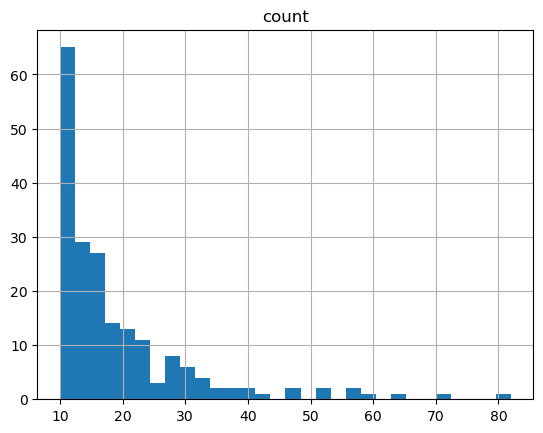

In [115]:
# plot the counts for the motifs at hand:
motif_of_interest_number.hist(column="count", bins=30)

### NGN2 neuron focus: 

filter for motif abundance: 


In [116]:
# # Optional: Filter Motifs by Overall Abundance:
# motif_of_interest_list = df_elements_bcalm_groups_fimo_info_filtered_effect["motif_id"].to_list()
# motif_of_interest_number = df_elements_bcalm_groups_fimo_info_filtered_effect.groupby("motif_id").size().reset_index()
# motif_of_interest_number.columns = ["motif_id", "count"]
# filter_motif_abundance = True
# if filter_motif_abundance:

#     # filter based on number
#     _motif_number_threshold = 10
#     _motif_number_threshold = 50
#     _motif_number_threshold = 100
#     # _motif_number_threshold = 150
#     _motif_number_threshold = motif_of_interest_number['count'].quantile(0.50)
#     print("Motif number threshold: ", _motif_number_threshold)
#     motif_of_interest_number = motif_of_interest_number.loc[motif_of_interest_number["count"] >= _motif_number_threshold].copy()
#     motif_of_interest_number
#     motif_of_interest_list = motif_of_interest_number["motif_id"].to_list()


In [117]:
# elements_fimo_motifs_filtered_bitscore_motif_number = df_elements_bcalm_groups_fimo_info_filtered_effect.loc[
    # df_elements_bcalm_groups_fimo_info_filtered_effect['motif_id'].isin(motif_of_interest_list)].copy()
elements_fimo_motifs_filtered_bitscore_motif_number = ngn2_df_elements_bcalm_groups_fimo_info_filtered_effect.loc[
    ngn2_df_elements_bcalm_groups_fimo_info_filtered_effect['motif_id'].isin(motif_of_interest_list)].copy()

# Transform your FIMO-like output to a sequence-centric DataFrame
# This step is crucial for accurate contingency tables (counting sequences, not motif occurrences)
ngn2_sequence_centric_df = process_fimo_output_to_sequence_motif_matrix(elements_fimo_motifs_filtered_bitscore_motif_number,
                                                                    sequence_id_col='name',
                                                                    motif_id_col='motif_id',
                                                                    effect_col='bcalm_effect_NGN2')


print(f"Transformed sequence-centric DataFrame shape: {ngn2_sequence_centric_df.shape}")

amount_of_motif_hits_looked_at = elements_fimo_motifs_filtered_bitscore_motif_number.shape[0] / ngn2_df_elements_bcalm_groups_fimo_info_filtered_effect.shape[0]
print(f"These {len(motif_of_interest_list)} differnet motifs are responsible for {round(amount_of_motif_hits_looked_at*100, 3)}% of the overall motif hits.")

# # generate the number of motifs for each sequence:
# ngn2_sequence_centric_df[list(ngn2_sequence_centric_df.columns)[2:]].sum(axis=1)

# # generate the number of motif hits overall (column sum)
# ngn2_sequence_centric_df[list(ngn2_sequence_centric_df.columns)[2:]].sum()

all_unique_motifs = list(set(ngn2_df_elements_bcalm_groups_fimo_info_filtered_effect['motif_id'].to_list()))
# Iterate through all unique motifs and run the enrichment analysis
results = {}
for motif_col in all_unique_motifs: # Iterate through the motif columns created by process_fimo_output_to_sequence_motif_matrix
    if motif_col in ngn2_sequence_centric_df.columns: # Check if motif column actually exists
        (or_inc, p_inc), (or_dec, p_dec), n_motif_found = analyze_motif_enrichment_sequence_centric(df_sequence_centric=ngn2_sequence_centric_df,
                                                                                                    motif_column_name=motif_col,
                                                                                                    bcalm_effect_col='bcalm_effect_NGN2')
        results[motif_col] = {
            'OR_Increasing': or_inc,
            'P_Increasing': p_inc,
            'OR_Decreasing': or_dec,
            'P_Decreasing': p_dec,
            'N_seq_with_motif': n_motif_found
        }

# Convert results to a DataFrame for easier handling
ngn2_results_df = pd.DataFrame.from_dict(results, orient='index')
ngn2_results_df.index.name = 'motif_id'

# Step 4: Apply Multiple Testing Correction
# Collect all p-values for increasing and decreasing separately
p_values_inc = ngn2_results_df['P_Increasing'].dropna().values
p_values_dec = ngn2_results_df['P_Decreasing'].dropna().values

if len(p_values_inc) > 0:
    # Use Benjamini-Hochberg FDR correction
    # `reject` is a boolean array, `pvals_corrected` are the adjusted p-values
    reject_inc, p_vals_inc_corrected = fdrcorrection(p_values_inc)
    ngn2_results_df.loc[ngn2_results_df['P_Increasing'].dropna().index, 'P_Increasing_FDR'] = p_vals_inc_corrected
else:
    ngn2_results_df['P_Increasing_FDR'] = np.nan

if len(p_values_dec) > 0:
    reject_dec, p_vals_dec_corrected = fdrcorrection(p_values_dec)
    ngn2_results_df.loc[ngn2_results_df['P_Decreasing'].dropna().index, 'P_Decreasing_FDR'] = p_vals_dec_corrected
else:
    ngn2_results_df['P_Decreasing_FDR'] = np.nan

# Example filtering for significant motifs
alpha = 0.1
significant_increasing_motifs = ngn2_results_df[
    (ngn2_results_df['P_Increasing_FDR'] < alpha)
].sort_values(by='OR_Increasing', ascending=False)

significant_decreasing_motifs = ngn2_results_df[
    (ngn2_results_df['P_Decreasing_FDR'] < alpha)
].sort_values(by='OR_Decreasing', ascending=False)

print(f"\nSignificant Increasing Motifs (FDR < {alpha}, OR > 1):")
print(significant_increasing_motifs.head())

print(f"\nSignificant Decreasing Motifs (FDR < {alpha}, OR > 1):")
print(significant_decreasing_motifs.head())

Transformed sequence-centric DataFrame shape: (1421, 199)
These 197 differnet motifs are responsible for 63.524% of the overall motif hits.

Significant Increasing Motifs (FDR < 0.1, OR > 1):
Empty DataFrame
Columns: [OR_Increasing, P_Increasing, OR_Decreasing, P_Decreasing, N_seq_with_motif, P_Increasing_FDR, P_Decreasing_FDR]
Index: []

Significant Decreasing Motifs (FDR < 0.1, OR > 1):
Empty DataFrame
Columns: [OR_Increasing, P_Increasing, OR_Decreasing, P_Decreasing, N_seq_with_motif, P_Increasing_FDR, P_Decreasing_FDR]
Index: []


In [118]:
ngn2_results_df

,OR_Increasing,P_Increasing,OR_Decreasing,P_Decreasing,N_seq_with_motif,P_Increasing_FDR,P_Decreasing_FDR
motif_id,,,,,,,
ZNF618.H13CORE.0.G.B,0.883367,0.817271,0.631519,0.583584,22,1.000000,1.0
TAL1.H13CORE.1.P.B,3.913000,0.093880,4.015805,0.115055,14,0.837375,1.0
ZN790.H13CORE.1.P.C,0.788275,0.776627,0.450956,0.494845,14,1.000000,1.0
ZN662.H13CORE.0.P.C,0.788275,0.776627,0.000000,0.047561,12,1.000000,1.0
ZNF746.H13CORE.0.PSG.A,1.109980,0.857972,0.588977,0.375761,38,1.000000,1.0
...,...,...,...,...,...,...,...
ZN502.H13CORE.0.P.C,0.884294,1.000000,0.633618,0.712745,11,1.000000,1.0
ZNF233.H13CORE.0.PG.A,1.331737,0.764835,0.633618,0.712745,13,1.000000,1.0
TF2LY.H13CORE.0.SM.B,2.227545,0.322051,1.594286,0.681529,12,0.946925,1.0


Add the gene symbol and the information if active in excitatory neurons

In [169]:
expected_tfbs_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/expected_TFBS_in_undiffWTC11_and_NGN2_neurons_cell_type_genexpression.tsv.gz"
active_tfs_neuro_undiff_cells = pd.read_csv(expected_tfbs_path, sep="\t", compression='gzip')
active_tfs_neuro_undiff_cells

active_tfs_neuro = active_tfs_neuro_undiff_cells.loc[active_tfs_neuro_undiff_cells['Excitatory neurons'] == 1][['Excitatory neurons', 'gene_symbol',
       'motif_id']].copy()
active_tfs_undiff_cells = active_tfs_neuro_undiff_cells.loc[active_tfs_neuro_undiff_cells['Undifferentiated cells'] == 1][['Undifferentiated cells', 'gene_symbol',
       'motif_id']].copy()

ngn2_results_hocomoco_tfbs = ngn2_results_df.merge(active_tfs_neuro, on="motif_id", how="left")
# for "Excitatory neurons" fill with 0 if NaN
ngn2_results_hocomoco_tfbs['Excitatory neurons'] = ngn2_results_hocomoco_tfbs['Excitatory neurons'].fillna(0).astype(float)
ngn2_results_hocomoco_tfbs['Excitatory neurons'] = ngn2_results_hocomoco_tfbs['Excitatory neurons'].astype(int)
ngn2_results_hocomoco_tfbs['Excitatory neurons'].value_counts()

Excitatory neurons
1    176
0     21
Name: count, dtype: int64

In [173]:
ngn2_results_hocomoco_tfbs

,motif_id,OR_Increasing,P_Increasing,OR_Decreasing,P_Decreasing,N_seq_with_motif,P_Increasing_FDR,P_Decreasing_FDR,Excitatory neurons,gene_symbol,is_enriched_increasing,is_depleted_increasing,is_enriched_decreasing,is_depleted_decreasing
0,ZNF618.H13CORE.0.G.B,0.883367,0.817271,0.631519,0.583584,22,1.000000,1.0,1,ZNF618,False,False,False,False
1,TAL1.H13CORE.1.P.B,3.913000,0.093880,4.015805,0.115055,14,0.837375,1.0,0,NaN,False,False,True,False
2,ZN790.H13CORE.1.P.C,0.788275,0.776627,0.450956,0.494845,14,1.000000,1.0,1,ZNF790,False,False,False,False
3,ZN662.H13CORE.0.P.C,0.788275,0.776627,0.000000,0.047561,12,1.000000,1.0,1,ZNF662,False,False,False,False
4,ZNF746.H13CORE.0.PSG.A,1.109980,0.857972,0.588977,0.375761,38,1.000000,1.0,1,ZNF746,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,ZN502.H13CORE.0.P.C,0.884294,1.000000,0.633618,0.712745,11,1.000000,1.0,1,ZNF502,False,False,False,False
193,ZNF233.H13CORE.0.PG.A,1.331737,0.764835,0.633618,0.712745,13,1.000000,1.0,1,ZNF233,False,False,False,False
194,TF2LY.H13CORE.0.SM.B,2.227545,0.322051,1.594286,0.681529,12,0.946925,1.0,0,NaN,False,False,False,False
195,ZN322.H13CORE.0.P.C,2.783865,0.266565,1.592593,0.642343,9,0.875222,1.0,1,ZNF322,False,False,False,False


##### Investigate the resulting set for the motifs with high effect sizes

I have now 4 sets of motifs which are enriched for motifs within sequences with increasing transcriptional activity (increasing_enriched_motif_id_set), depleted within sequences within increasing transcriptional activity (increasing_depleted_motif_id_set), enriched within sequences with decreasing sequences (decreasing_enriched_motif_id_set) and depeted within sequences with decreasing transciptional activity (decreasing_depleted_motif_id_set) based on their odds ratio.

Prepare the data for visualization

In [175]:
_odds_ratio_ngn2_increasing_upper_threshold = 2
_odds_ratio_ngn2_increasing_upper_threshold = ngn2_results_hocomoco_tfbs["OR_Increasing"].quantile(0.95)
_odds_ratio_ngn2_increasing_lower_threshold = 1
_odds_ratio_ngn2_increasing_lower_threshold = ngn2_results_hocomoco_tfbs["OR_Increasing"].quantile(0.05)
_odds_ratio_ngn2_decreasing_upper_threshold = 2
_odds_ratio_ngn2_decreasing_upper_threshold = ngn2_results_hocomoco_tfbs["OR_Decreasing"].quantile(0.95)
_odds_ratio_ngn2_decreasing_lower_threshold = 1
_odds_ratio_ngn2_decreasing_lower_threshold = ngn2_results_hocomoco_tfbs["OR_Decreasing"].quantile(0.05)

# get the list of motifs which have a higher odds ratio and investigate the size of the list
print(_odds_ratio_ngn2_increasing_upper_threshold)
ngn2_increasing_enriched_motifs = ngn2_results_hocomoco_tfbs.loc[ngn2_results_hocomoco_tfbs['OR_Increasing'] >= _odds_ratio_ngn2_increasing_upper_threshold].copy()
ngn2_increasing_enriched_motif_id_set = set(ngn2_increasing_enriched_motifs['motif_id'].to_list())
ngn2_results_hocomoco_tfbs['is_enriched_increasing'] = ngn2_results_hocomoco_tfbs['OR_Increasing'] >= _odds_ratio_ngn2_increasing_upper_threshold
print("Number of motifs which are likely enriched for increasing transcriptional activity: ", ngn2_increasing_enriched_motifs.shape[0])
print("Set of names: ", ngn2_increasing_enriched_motif_id_set)

# get the motifs which are likely depleted for sequences with increasing transcriptional activity
print(_odds_ratio_ngn2_increasing_lower_threshold)
ngn2_increasing_depleted_motifs = ngn2_results_hocomoco_tfbs.loc[ngn2_results_hocomoco_tfbs['OR_Increasing'] <= _odds_ratio_ngn2_increasing_lower_threshold].copy()
n = int(len(ngn2_results_hocomoco_tfbs) * 0.05)
ngn2_increasing_depleted_motifs = ngn2_results_hocomoco_tfbs.nsmallest(n, 'OR_Increasing').copy()
ngn2_increasing_depleted_motif_id_set = set(ngn2_increasing_depleted_motifs['motif_id'].to_list())
ngn2_results_hocomoco_tfbs['is_depleted_increasing'] = ngn2_results_hocomoco_tfbs['motif_id'].isin(ngn2_increasing_depleted_motif_id_set)
print("Number of motifs which are likely depleted for increased transcriptional activity: ", ngn2_increasing_depleted_motifs.shape[0])
print("Set of names: ", ngn2_increasing_depleted_motif_id_set)

# get the list of motifs likely enriched in decreasing sequences
print(_odds_ratio_ngn2_increasing_upper_threshold)
ngn2_decreasing_enriched_motifs = ngn2_results_hocomoco_tfbs.loc[ngn2_results_hocomoco_tfbs['OR_Decreasing'] >= _odds_ratio_ngn2_decreasing_upper_threshold].copy()
ngn2_decreasing_enriched_motif_id_set = set(ngn2_decreasing_enriched_motifs['motif_id'].to_list())
ngn2_results_hocomoco_tfbs['is_enriched_decreasing'] = ngn2_results_hocomoco_tfbs['OR_Decreasing'] >= _odds_ratio_ngn2_decreasing_upper_threshold
print("Number of motifs which are likely enriched for decreased transcriptional activity: ", ngn2_decreasing_enriched_motifs.shape[0])
print("Set of names: ", ngn2_decreasing_enriched_motif_id_set)

# get the motifs which are likely depleted for sequences with decreasing transcriptional activity
print(_odds_ratio_ngn2_decreasing_lower_threshold)
ngn2_decreasing_depleted_motifs = ngn2_results_hocomoco_tfbs.loc[ngn2_results_hocomoco_tfbs['OR_Decreasing'] <= _odds_ratio_ngn2_decreasing_lower_threshold].copy()
n = int(len(ngn2_results_hocomoco_tfbs) * 0.05)
ngn2_decreasing_depleted_motifs = ngn2_results_hocomoco_tfbs.nsmallest(n, 'OR_Decreasing').copy()
ngn2_decreasing_depleted_motif_id_set = set(ngn2_decreasing_depleted_motifs['motif_id'].to_list())
ngn2_results_hocomoco_tfbs['is_depleted_decreasing'] = ngn2_results_hocomoco_tfbs['motif_id'].isin(ngn2_decreasing_depleted_motif_id_set)
print("Number of motifs which are likely depleted for increasing transcriptional activity: ", ngn2_decreasing_depleted_motifs.shape[0])
print("Set of names: ", ngn2_decreasing_depleted_motif_id_set)


4.464442436291342
Number of motifs which are likely enriched for increasing transcriptional activity:  10
Set of names:  {'ZBTB6.H13CORE.0.P.B', 'ZNF16.H13CORE.0.P.C', 'ZNF800.H13CORE.0.PSG.A', 'ZN124.H13CORE.0.P.C', 'KMT2A.H13CORE.0.P.B', 'ZN714.H13CORE.0.P.C', 'KLF10.H13CORE.1.PSM.A', 'ZN610.H13CORE.0.P.B', 'ZN394.H13CORE.0.P.C', 'ZN671.H13CORE.0.P.C'}
0.27318485128830977
Number of motifs which are likely depleted for increased transcriptional activity:  9
Set of names:  {'HSF1.H13CORE.1.P.B', 'GRHL2.H13CORE.0.P.B', 'ZN860.H13CORE.0.P.C', 'ZN135.H13CORE.0.P.C', 'TTF1.H13CORE.0.PSG.A', 'STA5A.H13CORE.0.P.B', 'ZN283.H13CORE.0.P.C', 'ZNF79.H13CORE.0.P.C', 'ZN778.H13CORE.1.P.B'}
4.464442436291342
Number of motifs which are likely enriched for decreased transcriptional activity:  10
Set of names:  {'ZN484.H13CORE.0.P.C', 'ZBTB6.H13CORE.0.P.B', 'ZN567.H13CORE.0.P.C', 'ZN124.H13CORE.0.P.C', 'TAL1.H13CORE.1.P.B', 'ZN714.H13CORE.0.P.C', 'ZN431.H13CORE.0.P.C', 'ZN610.H13CORE.0.P.B', 'ZN394.H13

In [ ]:
ngn2_results_hocomoco_tfbs

In [ ]:
ngn2_results_hocomoco_tfbs.loc[ngn2_results_hocomoco_tfbs['is_enriched_increasing']]

,motif_id,OR_Increasing,P_Increasing,OR_Decreasing,P_Decreasing,N_seq_with_motif,P_Increasing_FDR,P_Decreasing_FDR,Excitatory neurons,gene_symbol,is_enriched_increasing,is_depleted_increasing,is_enriched_decreasing,is_depleted_decreasing
0,ZNF618.H13CORE.0.G.B,0.883367,0.817271,0.631519,0.583584,22,1.000000,1.0,1,ZNF618,False,False,False,False
1,TAL1.H13CORE.1.P.B,3.913000,0.093880,4.015805,0.115055,14,0.837375,1.0,0,NaN,False,False,True,False
2,ZN790.H13CORE.1.P.C,0.788275,0.776627,0.450956,0.494845,14,1.000000,1.0,1,ZNF790,False,False,False,False
3,ZN662.H13CORE.0.P.C,0.788275,0.776627,0.000000,0.047561,12,1.000000,1.0,1,ZNF662,False,False,False,True
4,ZNF746.H13CORE.0.PSG.A,1.109980,0.857972,0.588977,0.375761,38,1.000000,1.0,1,ZNF746,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,ZN502.H13CORE.0.P.C,0.884294,1.000000,0.633618,0.712745,11,1.000000,1.0,1,ZNF502,False,False,False,False
193,ZNF233.H13CORE.0.PG.A,1.331737,0.764835,0.633618,0.712745,13,1.000000,1.0,1,ZNF233,False,False,False,False
194,TF2LY.H13CORE.0.SM.B,2.227545,0.322051,1.594286,0.681529,12,0.946925,1.0,0,NaN,False,False,False,False
195,ZN322.H13CORE.0.P.C,2.783865,0.266565,1.592593,0.642343,9,0.875222,1.0,1,ZNF322,False,False,False,False


In [ ]:
ngn2_results_hocomoco_tfbs.groupby(['Excitatory neurons', 'is_enriched_increasing', 'is_depleted_increasing', 'is_enriched_decreasing', 'is_depleted_decreasing']).size()
# one motif which is not expected to be active in this cell-type seems to be enriched in the decreasing sequences: TAL1.H13CORE.1.P.B

ngn2_results_hocomoco_tfbs.loc[~ngn2_results_hocomoco_tfbs['is_enriched_increasing'] & ~ngn2_results_hocomoco_tfbs['is_depleted_increasing'] & ngn2_results_hocomoco_tfbs['is_enriched_decreasing'] & ~ngn2_results_hocomoco_tfbs['is_depleted_decreasing']]


,motif_id,OR_Increasing,P_Increasing,OR_Decreasing,P_Decreasing,N_seq_with_motif,P_Increasing_FDR,P_Decreasing_FDR,Excitatory neurons,gene_symbol,is_enriched_increasing,is_depleted_increasing,is_enriched_decreasing,is_depleted_decreasing
1,TAL1.H13CORE.1.P.B,3.913000,0.093880,4.015805,0.115055,14,0.837375,1.0,0,NaN,False,False,True,False
80,ZN484.H13CORE.0.P.C,1.106931,1.000000,4.015805,0.115055,9,1.000000,1.0,1,ZNF484,False,False,True,False
81,ZN567.H13CORE.0.P.C,2.783865,0.266565,4.832853,0.060869,13,0.875222,1.0,1,ZNF567,False,False,True,False
152,ZN431.H13CORE.0.P.C,0.552372,1.000000,4.015805,0.115055,8,1.000000,1.0,1,ZNF431,False,False,True,False


/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth

<Figure size 1000x600 with 0 Axes>

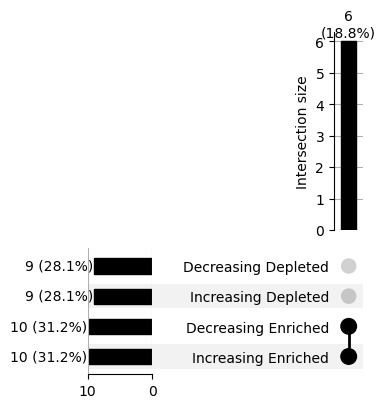

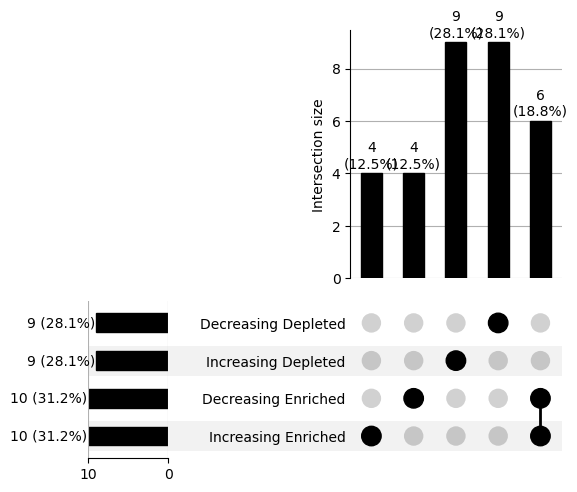

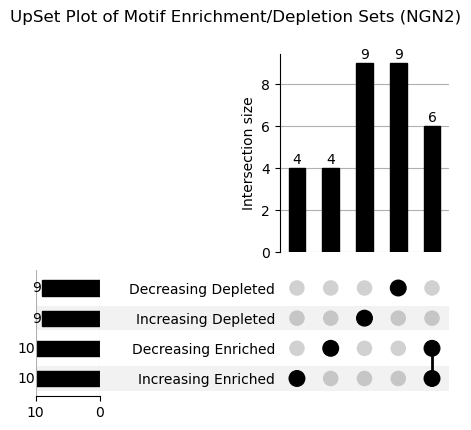

In [125]:
from upsetplot import UpSet
from upsetplot import from_contents
import matplotlib.pyplot as plt

# Your motif ID sets
contents = {
    'Increasing Enriched': ngn2_increasing_enriched_motif_id_set,
    'Increasing Depleted': ngn2_increasing_depleted_motif_id_set,
    'Decreasing Enriched': ngn2_decreasing_enriched_motif_id_set,
    'Decreasing Depleted': ngn2_decreasing_depleted_motif_id_set
}

# Convert to UpSet data
upset_data = from_contents(contents)

# Plot
plt.figure(figsize=(10, 6))
UpSet(upset_data, show_counts=True, min_degree=2, show_percentages=True).plot()
UpSet(upset_data, show_counts=True, show_percentages=True, element_size=40).plot()
UpSet(upset_data, show_counts=True).plot()
plt.suptitle("UpSet Plot of Motif Enrichment/Depletion Sets (NGN2)")
plt.tight_layout()
plt.show()


In [126]:
# investigate the sets:
# decreasing enriched and increasing enriched
ngn2_increasing_ngn2_decreasing_enriched = ngn2_increasing_enriched_motif_id_set.intersection(ngn2_decreasing_enriched_motif_id_set)
print("ngn2_increasing_ngn2_decreasing_enriched: ", ngn2_increasing_ngn2_decreasing_enriched)

ngn2_decreasing_enriched_ngn2_increasing_depleted = ngn2_decreasing_enriched_motif_id_set.intersection(ngn2_increasing_depleted_motif_id_set)
print("ngn2_decreasing_enriched_ngn2_increasing_depleted: ", ngn2_decreasing_enriched_ngn2_increasing_depleted) # https://www.genecards.org/cgi-bin/carddisp.pl?gene=GRHL2 (neuro development)

ngn2_decreasing_depleted_ngn2_increasing_enriched = ngn2_decreasing_depleted_motif_id_set.intersection(ngn2_increasing_enriched_motif_id_set)
print("ngn2_decreasing_depleted_ngn2_increasing_enriched: ", ngn2_decreasing_depleted_ngn2_increasing_enriched)

ngn2_decreasing_ngn2_increasing_depletion = ngn2_increasing_depleted_motif_id_set.intersection(ngn2_decreasing_depleted_motif_id_set)
print("ngn2_decreasing_ngn2_increasing_depletion: ", ngn2_decreasing_ngn2_increasing_depletion)

ngn2_increasing_ngn2_decreasing_enriched:  {'ZBTB6.H13CORE.0.P.B', 'ZN124.H13CORE.0.P.C', 'ZN714.H13CORE.0.P.C', 'ZN610.H13CORE.0.P.B', 'ZN394.H13CORE.0.P.C', 'ZN671.H13CORE.0.P.C'}
ngn2_decreasing_enriched_ngn2_increasing_depleted:  set()
ngn2_decreasing_depleted_ngn2_increasing_enriched:  set()
ngn2_decreasing_ngn2_increasing_depletion:  set()


##### Investigate the sequence set size of the resulting sequence sets at hand

In [127]:
elements_fimo_motifs_filtered_bitscore_motif_number_deduplicatd = elements_fimo_motifs_filtered_bitscore_motif_number.drop_duplicates(subset=[col_sequence]).copy()
elements_fimo_motifs_filtered_bitscore_motif_number_deduplicatd['bcalm_effect_NGN2'].value_counts()

bcalm_effect_NGN2
no_effect     561
increasing    507
decreasing    353
Name: count, dtype: int64

### Undifferentiacted WTC11 focus:

##### Investigate the sequence set size of the resulting sequence sets at hand

In [128]:
elements_fimo_motifs_filtered_bitscore_motif_number_deduplicatd = elements_fimo_motifs_filtered_bitscore_motif_number.drop_duplicates(subset=[col_sequence]).copy()
elements_fimo_motifs_filtered_bitscore_motif_number_deduplicatd['bcalm_effect_undiffWTC11'].value_counts()

bcalm_effect_undiffWTC11
no_effect     1365
increasing      34
decreasing      12
Name: count, dtype: int64

In [129]:
# elements_fimo_motifs_filtered_bitscore_motif_number = df_elements_bcalm_groups_fimo_info_filtered_effect.loc[
#     df_elements_bcalm_groups_fimo_info_filtered_effect['motif_id'].isin(motif_of_interest_list)].copy()
elements_fimo_motifs_filtered_bitscore_motif_number = undiffWTC11_df_elements_bcalm_groups_fimo_info_filtered_effect.loc[
    undiffWTC11_df_elements_bcalm_groups_fimo_info_filtered_effect['motif_id'].isin(motif_of_interest_list)].copy()

# Transform your FIMO-like output to a sequence-centric DataFrame
# This step is crucial for accurate contingency tables (counting sequences, not motif occurrences)
undiffWTC11_sequence_centric = process_fimo_output_to_sequence_motif_matrix(elements_fimo_motifs_filtered_bitscore_motif_number,
                                                                    sequence_id_col='name',
                                                                    motif_id_col='motif_id',
                                                                    effect_col='bcalm_effect_undiffWTC11')


print(f"Transformed sequence-centric DataFrame shape: {undiffWTC11_sequence_centric.shape}")

amount_of_motif_hits_looked_at = elements_fimo_motifs_filtered_bitscore_motif_number.shape[0] / undiffWTC11_df_elements_bcalm_groups_fimo_info_filtered_effect.shape[0]
print(f"These {len(motif_of_interest_list)} differnet motifs are responsible for {round(amount_of_motif_hits_looked_at*100, 3)}% of the overall motif hits.")

# # generate the number of motifs for each sequence:
# undiffWTC11_sequence_centric[list(undiffWTC11_sequence_centric.columns)[2:]].sum(axis=1)

# # generate the number of motif hits overall (column sum)
# undiffWTC11_sequence_centric[list(undiffWTC11_sequence_centric.columns)[2:]].sum()

all_unique_motifs = list(set(undiffWTC11_df_elements_bcalm_groups_fimo_info_filtered_effect['motif_id'].to_list()))
# Iterate through all unique motifs and run the enrichment analysis
results = {}
for motif_col in all_unique_motifs: # Iterate through the motif columns created by process_fimo_output_to_sequence_motif_matrix
    if motif_col in undiffWTC11_sequence_centric.columns: # Check if motif column actually exists
        (or_inc, p_inc), (or_dec, p_dec), n_motif_found = analyze_motif_enrichment_sequence_centric(df_sequence_centric=undiffWTC11_sequence_centric,
                                                                                                    motif_column_name=motif_col,
                                                                                                    bcalm_effect_col='bcalm_effect_undiffWTC11')
        results[motif_col] = {
            'OR_Increasing': or_inc,
            'P_Increasing': p_inc,
            'OR_Decreasing': or_dec,
            'P_Decreasing': p_dec,
            'N_seq_with_motif': n_motif_found
        }

# Convert results to a DataFrame for easier handling
undiffWTC11_results_df = pd.DataFrame.from_dict(results, orient='index')
undiffWTC11_results_df.index.name = 'motif_id'

# Step 4: Apply Multiple Testing Correction
# Collect all p-values for increasing and decreasing separately
p_values_inc = undiffWTC11_results_df['P_Increasing'].dropna().values
p_values_dec = undiffWTC11_results_df['P_Decreasing'].dropna().values

if len(p_values_inc) > 0:
    # Use Benjamini-Hochberg FDR correction
    # `reject` is a boolean array, `pvals_corrected` are the adjusted p-values
    reject_inc, p_vals_inc_corrected = fdrcorrection(p_values_inc)
    undiffWTC11_results_df.loc[undiffWTC11_results_df['P_Increasing'].dropna().index, 'P_Increasing_FDR'] = p_vals_inc_corrected
else:
    undiffWTC11_results_df['P_Increasing_FDR'] = np.nan

if len(p_values_dec) > 0:
    reject_dec, p_vals_dec_corrected = fdrcorrection(p_values_dec)
    undiffWTC11_results_df.loc[undiffWTC11_results_df['P_Decreasing'].dropna().index, 'P_Decreasing_FDR'] = p_vals_dec_corrected
else:
    undiffWTC11_results_df['P_Decreasing_FDR'] = np.nan

# Example filtering for significant motifs
alpha = 0.1
significant_increasing_motifs = undiffWTC11_results_df[
    (undiffWTC11_results_df['P_Increasing_FDR'] < alpha)
].sort_values(by='OR_Increasing', ascending=False)

significant_decreasing_motifs = undiffWTC11_results_df[
    (undiffWTC11_results_df['P_Decreasing_FDR'] < alpha)
].sort_values(by='OR_Decreasing', ascending=False)

print(f"\nSignificant Increasing Motifs (FDR < {alpha}, OR > 1):")
print(significant_increasing_motifs.head())

print(f"\nSignificant Decreasing Motifs (FDR < {alpha}, OR > 1):")
print(significant_decreasing_motifs.head())

Transformed sequence-centric DataFrame shape: (884, 199)
These 197 differnet motifs are responsible for 66.537% of the overall motif hits.

Significant Increasing Motifs (FDR < 0.1, OR > 1):
Empty DataFrame
Columns: [OR_Increasing, P_Increasing, OR_Decreasing, P_Decreasing, N_seq_with_motif, P_Increasing_FDR, P_Decreasing_FDR]
Index: []

Significant Decreasing Motifs (FDR < 0.1, OR > 1):
Empty DataFrame
Columns: [OR_Increasing, P_Increasing, OR_Decreasing, P_Decreasing, N_seq_with_motif, P_Increasing_FDR, P_Decreasing_FDR]
Index: []


In [130]:
undiffWTC11_results_df

,OR_Increasing,P_Increasing,OR_Decreasing,P_Decreasing,N_seq_with_motif,P_Increasing_FDR,P_Decreasing_FDR
motif_id,,,,,,,
ZNF618.H13CORE.0.G.B,1.721875,0.365715,0.0,1.0,12,1.0,1.0
TAL1.H13CORE.1.P.B,0.000000,1.000000,0.0,1.0,4,1.0,1.0
ZN790.H13CORE.1.P.C,1.217582,0.591435,0.0,1.0,11,1.0,1.0
ZN662.H13CORE.0.P.C,0.000000,1.000000,0.0,1.0,9,1.0,1.0
ZNF746.H13CORE.0.PSG.A,1.622024,0.439505,0.0,1.0,32,1.0,1.0
...,...,...,...,...,...,...,...
ZN502.H13CORE.0.P.C,0.000000,1.000000,0.0,1.0,6,1.0,1.0
ZNF233.H13CORE.0.PG.A,0.000000,1.000000,0.0,1.0,8,1.0,1.0
TF2LY.H13CORE.0.SM.B,0.000000,1.000000,0.0,1.0,4,1.0,1.0


In [162]:
expected_tfbs_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/expected_TFBS_in_undiffWTC11_and_NGN2_neurons_cell_type_genexpression.tsv.gz"
active_tfs_neuro_undiff_cells = pd.read_csv(expected_tfbs_path, sep="\t", compression='gzip')
active_tfs_neuro_undiff_cells

active_tfs_neuro = active_tfs_neuro_undiff_cells.loc[active_tfs_neuro_undiff_cells['Excitatory neurons'] == 1][['Excitatory neurons', 'gene_symbol',
       'motif_id']].copy()
active_tfs_undiff_cells = active_tfs_neuro_undiff_cells.loc[active_tfs_neuro_undiff_cells['Undifferentiated cells'] == 1][['Undifferentiated cells', 'gene_symbol',
       'motif_id']].copy()

In [163]:
active_tfs_neuro_undiff_cells.columns

Index(['Excitatory neurons', 'Undifferentiated cells', 'gene_symbol',
       'motif_id', 'uniprot_id', 'uniprot_accession_num', 'cluster_motifs',
       'is_TFBS'],
      dtype='object')

In [164]:
active_tfs_undiff_cells.columns

Index(['Undifferentiated cells', 'gene_symbol', 'motif_id'], dtype='object')

In [165]:
undiffWTC11_results_hocomoco_tfbs = undiffWTC11_results_df.merge(active_tfs_undiff_cells, on="motif_id", how="left")
# for "Undifferentiated cells" fill with 0 if NaN
undiffWTC11_results_hocomoco_tfbs['Undifferentiated cells'] = undiffWTC11_results_hocomoco_tfbs['Undifferentiated cells'].fillna(0).astype(float)
undiffWTC11_results_hocomoco_tfbs['Undifferentiated cells'] = undiffWTC11_results_hocomoco_tfbs['Undifferentiated cells'].astype(int)
undiffWTC11_results_hocomoco_tfbs

,motif_id,OR_Increasing,P_Increasing,OR_Decreasing,P_Decreasing,N_seq_with_motif,P_Increasing_FDR,P_Decreasing_FDR,Undifferentiated cells,gene_symbol
0,ZNF618.H13CORE.0.G.B,1.721875,0.365715,0.0,1.0,12,1.0,1.0,1,ZNF618
1,TAL1.H13CORE.1.P.B,0.000000,1.000000,0.0,1.0,4,1.0,1.0,0,NaN
2,ZN790.H13CORE.1.P.C,1.217582,0.591435,0.0,1.0,11,1.0,1.0,1,ZNF790
3,ZN662.H13CORE.0.P.C,0.000000,1.000000,0.0,1.0,9,1.0,1.0,1,ZNF662
4,ZNF746.H13CORE.0.PSG.A,1.622024,0.439505,0.0,1.0,32,1.0,1.0,1,ZNF746
...,...,...,...,...,...,...,...,...,...,...
192,ZN502.H13CORE.0.P.C,0.000000,1.000000,0.0,1.0,6,1.0,1.0,1,ZNF502
193,ZNF233.H13CORE.0.PG.A,0.000000,1.000000,0.0,1.0,8,1.0,1.0,1,ZNF233
194,TF2LY.H13CORE.0.SM.B,0.000000,1.000000,0.0,1.0,4,1.0,1.0,0,NaN
195,ZN322.H13CORE.0.P.C,0.000000,1.000000,0.0,1.0,4,1.0,1.0,1,ZNF322


In [160]:
undiffWTC11_results_hocomoco_tfbs['Undifferentiated cells'].value_counts()

Undifferentiated cells
1    176
0     21
Name: count, dtype: int64

In [181]:
ngn2_results_hocomoco_tfbs.columns

Index(['motif_id', 'OR_Increasing', 'P_Increasing', 'OR_Decreasing',
       'P_Decreasing', 'N_seq_with_motif', 'P_Increasing_FDR',
       'P_Decreasing_FDR', 'Excitatory neurons', 'gene_symbol',
       'is_enriched_increasing', 'is_depleted_increasing',
       'is_enriched_decreasing', 'is_depleted_decreasing'],
      dtype='object')

In [183]:
_odds_ratio_undiffWTC11_increasing_upper_threshold = 2
_odds_ratio_undiffWTC11_increasing_upper_threshold = undiffWTC11_results_hocomoco_tfbs["OR_Increasing"].quantile(0.95)
_odds_ratio_undiffWTC11_increasing_lower_threshold = 1
_odds_ratio_undiffWTC11_increasing_lower_threshold = undiffWTC11_results_hocomoco_tfbs["OR_Increasing"].quantile(0.05)
_odds_ratio_undiffWTC11_decreasing_upper_threshold = 2
_odds_ratio_undiffWTC11_decreasing_upper_threshold = undiffWTC11_results_hocomoco_tfbs["OR_Decreasing"].quantile(0.95)
_odds_ratio_undiffWTC11_decreasing_lower_threshold = 1
_odds_ratio_undiffWTC11_decreasing_lower_threshold = undiffWTC11_results_hocomoco_tfbs["OR_Decreasing"].quantile(0.05)

# get the list of motifs which have a higher odds ratio and investigate the size of the list
print(_odds_ratio_undiffWTC11_increasing_upper_threshold)
undiffWTC11_increasing_enriched_motifs = undiffWTC11_results_hocomoco_tfbs.loc[undiffWTC11_results_hocomoco_tfbs['OR_Increasing'] >= _odds_ratio_undiffWTC11_increasing_upper_threshold].copy()
undiffWTC11_increasing_enriched_motif_id_set = set(undiffWTC11_increasing_enriched_motifs["motif_id"].to_list())
undiffWTC11_results_hocomoco_tfbs['is_enriched_increasing'] = undiffWTC11_results_hocomoco_tfbs['OR_Increasing'] >= _odds_ratio_undiffWTC11_increasing_upper_threshold
print("Number of motifs which are likely enriched for increasing transcriptional activity: ", undiffWTC11_increasing_enriched_motifs.shape[0])
print("Set of names: ", undiffWTC11_increasing_enriched_motif_id_set)

# get the motifs which are likely depleted for sequences with increasing transcriptional activity
print(_odds_ratio_undiffWTC11_increasing_lower_threshold)
undiffWTC11_increasing_depleted_motifs = undiffWTC11_results_hocomoco_tfbs.loc[undiffWTC11_results_hocomoco_tfbs['OR_Increasing'] <= _odds_ratio_undiffWTC11_increasing_lower_threshold].copy()
n = int(len(undiffWTC11_results_hocomoco_tfbs) * 0.05)
undiffWTC11_increasing_depleted_motifs = undiffWTC11_results_hocomoco_tfbs.nsmallest(n, 'OR_Increasing').copy()
undiffWTC11_increasing_depleted_motif_id_set = set(undiffWTC11_increasing_depleted_motifs["motif_id"].to_list())
undiffWTC11_results_hocomoco_tfbs['is_depleted_increasing'] = undiffWTC11_results_hocomoco_tfbs['motif_id'].isin(undiffWTC11_increasing_depleted_motif_id_set)
print("Number of motifs which are likely depleted for increased transcriptional activity: ", undiffWTC11_increasing_depleted_motifs.shape[0])
print("Set of names: ", undiffWTC11_increasing_depleted_motif_id_set)

# get the list of motifs likely enriched in decreasing sequences
print(_odds_ratio_undiffWTC11_increasing_upper_threshold)
undiffWTC11_decreasing_enriched_motifs = undiffWTC11_results_hocomoco_tfbs.loc[undiffWTC11_results_hocomoco_tfbs['OR_Decreasing'] >= _odds_ratio_undiffWTC11_decreasing_upper_threshold].copy()
undiffWTC11_decreasing_enriched_motif_id_set = set(undiffWTC11_decreasing_enriched_motifs["motif_id"].to_list())
undiffWTC11_results_hocomoco_tfbs['is_enriched_decreasing'] = undiffWTC11_results_hocomoco_tfbs['OR_Decreasing'] >= _odds_ratio_undiffWTC11_decreasing_upper_threshold
print("Number of motifs which are likely enriched for decreased transcriptional activity: ", undiffWTC11_decreasing_enriched_motifs.shape[0])
print("Set of names: ", undiffWTC11_decreasing_enriched_motif_id_set)

# get the motifs which are likely depleted for sequences with decreasing transcriptional activity
print(_odds_ratio_undiffWTC11_decreasing_lower_threshold)
undiffWTC11_decreasing_depleted_motifs = undiffWTC11_results_hocomoco_tfbs.loc[undiffWTC11_results_hocomoco_tfbs['OR_Decreasing'] <= _odds_ratio_undiffWTC11_decreasing_lower_threshold].copy()
n = int(len(undiffWTC11_results_hocomoco_tfbs) * 0.05)
undiffWTC11_decreasing_depleted_motifs = undiffWTC11_results_hocomoco_tfbs.nsmallest(n, 'OR_Decreasing').copy()
undiffWTC11_decreasing_depleted_motif_id_set = set(undiffWTC11_decreasing_depleted_motifs["motif_id"].to_list())
undiffWTC11_results_hocomoco_tfbs['is_depleted_decreasing'] = undiffWTC11_results_hocomoco_tfbs['motif_id'].isin(undiffWTC11_decreasing_depleted_motif_id_set)
print("Number of motifs which are likely depleted for increasing transcriptional activity: ", undiffWTC11_decreasing_depleted_motifs.shape[0])
print("Set of names: ", undiffWTC11_decreasing_depleted_motif_id_set)


5.8125
Number of motifs which are likely enriched for increasing transcriptional activity:  14
Set of names:  {'ZN320.H13CORE.1.P.B', 'ZNF44.H13CORE.0.P.C', 'PRDM6.H13CORE.0.P.B', 'ZN263.H13CORE.0.PM.A', 'KMT2A.H13CORE.0.P.B', 'ZN714.H13CORE.0.P.C', 'ZN610.H13CORE.0.P.B', 'REST.H13CORE.0.P.B', 'KLF10.H13CORE.1.PSM.A', 'ZN449.H13CORE.1.S.C', 'ZN623.H13CORE.0.P.C', 'ZN692.H13CORE.0.P.C', 'ZSCA1.H13CORE.0.SM.B', 'ZN671.H13CORE.0.P.C'}
0.0
Number of motifs which are likely depleted for increased transcriptional activity:  9
Set of names:  {'ZN543.H13CORE.0.P.C', 'ZN662.H13CORE.0.P.C', 'ZN528.H13CORE.0.P.B', 'TAL1.H13CORE.1.P.B', 'ZN141.H13CORE.0.P.C', 'ZF69B.H13CORE.0.P.C', 'ZN682.H13CORE.0.P.B', 'HIC2.H13CORE.0.P.B', 'ZN449.H13CORE.0.P.B'}
5.8125
Number of motifs which are likely enriched for decreased transcriptional activity:  11
Set of names:  {'ZN484.H13CORE.0.P.C', 'Z280A.H13CORE.0.P.B', 'Z585A.H13CORE.0.P.C', 'RFX4.H13CORE.0.SM.B', 'ZN567.H13CORE.0.P.C', 'PATZ1.H13CORE.0.P.B', 'HAND

In [ ]:
undiffWTC11_results_hocomoco_tfbs.groupby(['Undifferentiated cells', 'is_enriched_increasing', 'is_depleted_increasing', 'is_enriched_decreasing', 'is_depleted_decreasing']).size()
# 5 Motifs seem to have an effect which we would not expect based on genexpression data in a close cell-type


# undiffWTC11_results_hocomoco_tfbs.loc[~undiffWTC11_results_hocomoco_tfbs['Undifferentiated cells'] & ~undiffWTC11_results_hocomoco_tfbs['is_enriched_increasing'] & ~undiffWTC11_results_hocomoco_tfbs['is_depleted_increasing'] & ~undiffWTC11_results_hocomoco_tfbs['is_enriched_decreasing'] & undiffWTC11_results_hocomoco_tfbs['is_depleted_decreasing']]
# undiffWTC11_results_hocomoco_tfbs.loc[~undiffWTC11_results_hocomoco_tfbs['Undifferentiated cells'] & ~undiffWTC11_results_hocomoco_tfbs['is_enriched_increasing'] & ~undiffWTC11_results_hocomoco_tfbs['is_depleted_increasing'] & undiffWTC11_results_hocomoco_tfbs['is_enriched_decreasing'] & ~undiffWTC11_results_hocomoco_tfbs['is_depleted_decreasing']]
# undiffWTC11_results_hocomoco_tfbs.loc[~undiffWTC11_results_hocomoco_tfbs['Undifferentiated cells'] & ~undiffWTC11_results_hocomoco_tfbs['is_enriched_increasing'] & undiffWTC11_results_hocomoco_tfbs['is_depleted_increasing'] & ~undiffWTC11_results_hocomoco_tfbs['is_enriched_decreasing'] & ~undiffWTC11_results_hocomoco_tfbs['is_depleted_decreasing']]
# undiffWTC11_results_hocomoco_tfbs.loc[~undiffWTC11_results_hocomoco_tfbs['Undifferentiated cells'] & undiffWTC11_results_hocomoco_tfbs['is_enriched_increasing'] & ~undiffWTC11_results_hocomoco_tfbs['is_depleted_increasing'] & ~undiffWTC11_results_hocomoco_tfbs['is_enriched_decreasing'] & ~undiffWTC11_results_hocomoco_tfbs['is_depleted_decreasing']]



Undifferentiated cells  is_enriched_increasing  is_depleted_increasing  is_enriched_decreasing  is_depleted_decreasing
0                       False                   False                   False                   False                      16
                                                                                                True                        1
                                                                        True                    False                       2
                                                True                    False                   True                        1
                        True                    False                   False                   False                       1
1                       False                   False                   False                   False                     144
                                                                                                True                        4

5 Motifs seem to have an effect which we would not expect based on genexpression data in a close cell-type
PIT1.H13CORE.1.S.B which seems to be depleted in decreasing sequences (not reliable low number of counts)
RFX4.H13CORE.0.SM.B, ZNF732.H13CORE.0.PSG.A which seem to be enriched in decreasing sequences (is_enriched_decreasing)
TAL1.H13CORE.1.P.B again which is depleted in increasing and decreasing sequences
ZSCA1.H13CORE.0.SM.B which is enriched in increasing sequences

In [191]:
undiffWTC11_results_hocomoco_tfbs.loc[~undiffWTC11_results_hocomoco_tfbs['Undifferentiated cells'] & ~undiffWTC11_results_hocomoco_tfbs['is_enriched_increasing'] & ~undiffWTC11_results_hocomoco_tfbs['is_depleted_increasing'] & ~undiffWTC11_results_hocomoco_tfbs['is_enriched_decreasing'] & undiffWTC11_results_hocomoco_tfbs['is_depleted_decreasing']]


,motif_id,OR_Increasing,P_Increasing,OR_Decreasing,P_Decreasing,N_seq_with_motif,P_Increasing_FDR,P_Decreasing_FDR,Undifferentiated cells,gene_symbol,is_enriched_increasing,is_depleted_increasing,is_enriched_decreasing,is_depleted_decreasing
5,PIT1.H13CORE.1.S.B,2.861538,0.359837,0.0,1.0,4,1.0,1.0,0,NaN,False,False,False,True


In [192]:
undiffWTC11_results_hocomoco_tfbs.loc[~undiffWTC11_results_hocomoco_tfbs['Undifferentiated cells'] & ~undiffWTC11_results_hocomoco_tfbs['is_enriched_increasing'] & ~undiffWTC11_results_hocomoco_tfbs['is_depleted_increasing'] & undiffWTC11_results_hocomoco_tfbs['is_enriched_decreasing'] & ~undiffWTC11_results_hocomoco_tfbs['is_depleted_decreasing']]


,motif_id,OR_Increasing,P_Increasing,OR_Decreasing,P_Decreasing,N_seq_with_motif,P_Increasing_FDR,P_Decreasing_FDR,Undifferentiated cells,gene_symbol,is_enriched_increasing,is_depleted_increasing,is_enriched_decreasing,is_depleted_decreasing
83,RFX4.H13CORE.0.SM.B,2.861538,0.359837,15.5,0.087783,5,1.0,1.0,0,NaN,False,False,True,False
91,ZNF732.H13CORE.0.PSG.A,0.000000,1.000000,15.5,0.087783,6,1.0,1.0,0,NaN,False,False,True,False


In [194]:
undiffWTC11_results_hocomoco_tfbs.loc[~undiffWTC11_results_hocomoco_tfbs['Undifferentiated cells'] & ~undiffWTC11_results_hocomoco_tfbs['is_enriched_increasing'] & undiffWTC11_results_hocomoco_tfbs['is_depleted_increasing'] & ~undiffWTC11_results_hocomoco_tfbs['is_enriched_decreasing'] & undiffWTC11_results_hocomoco_tfbs['is_depleted_decreasing']]


,motif_id,OR_Increasing,P_Increasing,OR_Decreasing,P_Decreasing,N_seq_with_motif,P_Increasing_FDR,P_Decreasing_FDR,Undifferentiated cells,gene_symbol,is_enriched_increasing,is_depleted_increasing,is_enriched_decreasing,is_depleted_decreasing
1,TAL1.H13CORE.1.P.B,0.0,1.0,0.0,1.0,4,1.0,1.0,0,NaN,False,True,False,True


In [195]:
undiffWTC11_results_hocomoco_tfbs.loc[~undiffWTC11_results_hocomoco_tfbs['Undifferentiated cells'] & undiffWTC11_results_hocomoco_tfbs['is_enriched_increasing'] & ~undiffWTC11_results_hocomoco_tfbs['is_depleted_increasing'] & ~undiffWTC11_results_hocomoco_tfbs['is_enriched_decreasing'] & ~undiffWTC11_results_hocomoco_tfbs['is_depleted_decreasing']]


,motif_id,OR_Increasing,P_Increasing,OR_Decreasing,P_Decreasing,N_seq_with_motif,P_Increasing_FDR,P_Decreasing_FDR,Undifferentiated cells,gene_symbol,is_enriched_increasing,is_depleted_increasing,is_enriched_decreasing,is_depleted_decreasing
139,ZSCA1.H13CORE.0.SM.B,8.734375,0.056965,0.0,1.0,8,0.863232,1.0,0,NaN,True,False,False,False


/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth

<Figure size 1000x600 with 0 Axes>

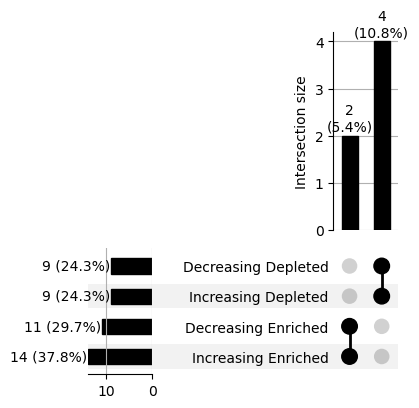

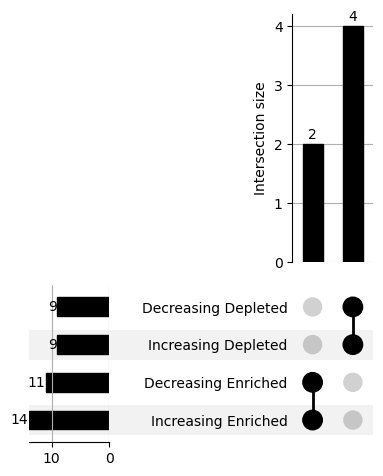

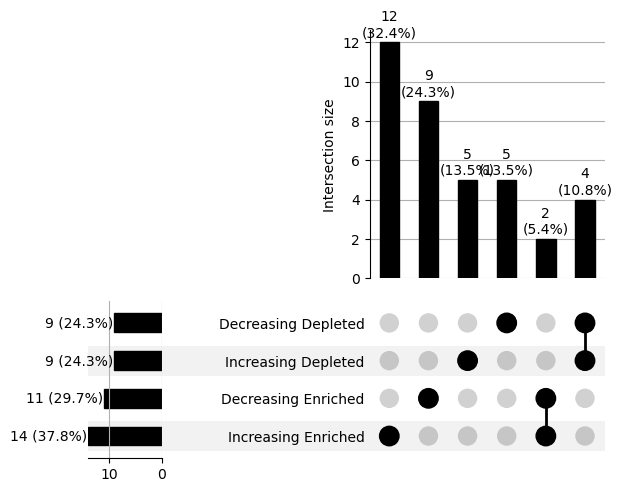

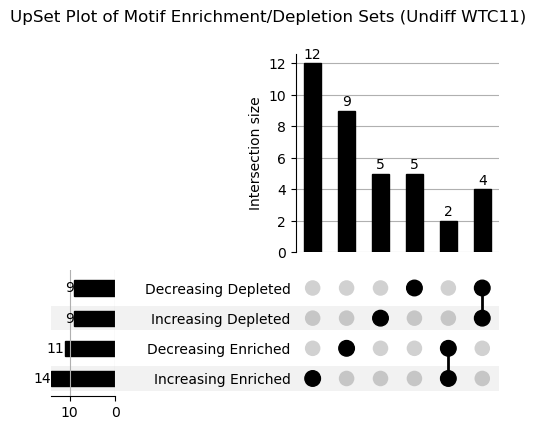

In [132]:
from upsetplot import UpSet
from upsetplot import from_contents
import matplotlib.pyplot as plt

# Your motif ID sets
contents = {
    'Increasing Enriched': undiffWTC11_increasing_enriched_motif_id_set,
    'Increasing Depleted': undiffWTC11_increasing_depleted_motif_id_set,
    'Decreasing Enriched': undiffWTC11_decreasing_enriched_motif_id_set,
    'Decreasing Depleted': undiffWTC11_decreasing_depleted_motif_id_set
}

# Convert to UpSet data
upset_data = from_contents(contents)

# Plot
plt.figure(figsize=(10, 6))
UpSet(upset_data, show_counts=True, min_degree=2, show_percentages=True).plot()
UpSet(upset_data, show_counts=True, min_degree=2, element_size=40).plot()
UpSet(upset_data, show_counts=True, show_percentages=True, element_size=40).plot()
UpSet(upset_data, show_counts=True).plot()
plt.suptitle("UpSet Plot of Motif Enrichment/Depletion Sets (Undiff WTC11)")
plt.tight_layout()
plt.show()


In [133]:
# investigate the sets:
# decreasing enriched and increasing enriched
increasing_decreasing_enriched = increasing_enriched_motif_id_set.intersection(decreasing_enriched_motif_id_set)
print("increasing_decreasing_enriched: ", increasing_decreasing_enriched)

decreasing_enriched_increasing_depleted = decreasing_enriched_motif_id_set.intersection(increasing_depleted_motif_id_set)
print("decreasing_enriched_increasing_depleted: ", decreasing_enriched_increasing_depleted) # https://www.genecards.org/cgi-bin/carddisp.pl?gene=GRHL2 (neuro development)

decreasing_depleted_increasing_enriched = decreasing_depleted_motif_id_set.intersection(increasing_enriched_motif_id_set)
print("decreasing_depleted_increasing_enriched: ", decreasing_depleted_increasing_enriched)

decreasing_increasing_depletion = increasing_depleted_motif_id_set.intersection(decreasing_depleted_motif_id_set)
print("decreasing_increasing_depletion: ", decreasing_increasing_depletion)

increasing_decreasing_enriched:  {'ZBTB6.H13CORE.0.P.B', 'ZN124.H13CORE.0.P.C', 'ZN714.H13CORE.0.P.C', 'ZN610.H13CORE.0.P.B', 'ZN394.H13CORE.0.P.C', 'ZN671.H13CORE.0.P.C'}
decreasing_enriched_increasing_depleted:  set()
decreasing_depleted_increasing_enriched:  set()
decreasing_increasing_depletion:  set()


#### Check if the identified TFBS sets are overlapping expected expressed TFBS in this cell-type

In [ ]:
expected_tfbs_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/expected_TFBS_in_undiffWTC11_and_NGN2_neurons_cell_type_genexpression.tsv.gz"
active_tfs_neuro_undiff_cells = pd.read_csv(expected_tfbs_path, sep="\t", compression='gzip')
active_tfs_neuro_undiff_cells

active_tfs_neuro = active_tfs_neuro_undiff_cells.loc[active_tfs_neuro_undiff_cells['Excitatory neurons'] == 1].copy()
active_tfs_undiff_cells = active_tfs_neuro_undiff_cells.loc[active_tfs_neuro_undiff_cells['Undifferentiated cells'] == 1].copy()

,Excitatory neurons,Undifferentiated cells,gene_symbol,motif_id,uniprot_id,uniprot_accession_num,cluster_motifs,is_TFBS
0,1,1,AHCTF1,AHCTF1.H13CORE.0.B.B,ELYS_HUMAN,Q8WYP5,"['AHCTF1.H13CORE.0.B.B', 'GLYR1.H13CORE.0.B.B']",1.0
1,1,1,AHR,AHR.H13CORE.0.P.B,AHR_HUMAN,P35869,"['AHR.H13CORE.0.P.B', 'AHRR.H13CORE.0.P.C']",1.0
2,0,1,ALX1,ALX1.H13CORE.0.SM.B,ALX1_HUMAN,Q15699,"['ALX1.H13CORE.0.SM.B', 'ALX4.H13CORE.0.S.B', ...",1.0
3,1,1,AR,ANDR.H13CORE.2.P.B,ANDR_HUMAN,P10275,['ANDR.H13CORE.2.P.B'],1.0
4,1,1,AR,ANDR.H13CORE.1.S.C,ANDR_HUMAN,P10275,"['ANDR.H13CORE.1.S.C', 'GCR.H13CORE.1.S.B', 'M...",1.0
...,...,...,...,...,...,...,...,...
601,1,1,ZSCAN29,ZSC29.H13CORE.1.M.C,ZSC29_HUMAN,Q8IWY8,['ZSC29.H13CORE.1.M.C'],1.0
602,1,1,ZSCAN31,ZSC31.H13CORE.0.P.C,ZSC31_HUMAN,Q96LW9,"['ZSC31.H13CORE.0.P.C', 'ZSC31.H13CORE.1.SM.B']",1.0
603,1,1,ZSCAN5A,ZSA5A.H13CORE.0.SM.B,ZSA5A_HUMAN,Q9BUG6,['ZSA5A.H13CORE.0.SM.B'],1.0
604,1,1,ZXDA,ZXDA.H13CORE.0.PSI.A,ZXDA_HUMAN,P98168,"['ZXDA.H13CORE.0.PSI.A', 'ZXDB.H13CORE.0.PI.A']",1.0


In [143]:
active_tfs = active_tfs_neuro.copy()

In [145]:
active_tfs.columns

Index(['Excitatory neurons', 'Undifferentiated cells', 'gene_symbol',
       'motif_id', 'uniprot_id', 'uniprot_accession_num', 'cluster_motifs',
       'is_TFBS'],
      dtype='object')

,motif_id,gene_symbol,uniprot_id,uniprot_accession_num,cluster_motifs
0,ZBED5.H13CORE.0.PSGIB.A,ZBED5,ZBED5_HUMAN,Q49AG3,[ZBED5.H13CORE.0.PSGIB.A]
1,ZFAT.H13CORE.0.PSGI.A,ZFAT,ZFAT_HUMAN,Q9P243,[ZFAT.H13CORE.0.PSGI.A]
2,ZSCAN2.H13CORE.0.PG.A,ZSCAN2,ZSCA2_HUMAN,Q7Z7L9,[ZSCAN2.H13CORE.0.PG.A]
3,ZFTA.H13CORE.0.PSGIB.A,ZFTA,ZFTA_HUMAN,C9JLR9,[ZFTA.H13CORE.0.PSGIB.A]
4,ZNF226.H13CORE.0.PSGI.A,ZNF226,ZN226_HUMAN,Q9NYT6,"[ZNF226.H13CORE.0.PSGI.A, ZNF234.H13CORE.0.PSG.A]"
...,...,...,...,...,...
648,ZSC23.H13CORE.0.M.C,ZSCAN23,ZSC23_HUMAN,Q3MJ62,[ZSC23.H13CORE.0.M.C]
649,ZSC29.H13CORE.0.P.B,ZSCAN29,ZSC29_HUMAN,Q8IWY8,[ZSC29.H13CORE.0.P.B]
650,ZSC29.H13CORE.1.M.C,ZSCAN29,ZSC29_HUMAN,Q8IWY8,[ZSC29.H13CORE.1.M.C]
651,ZSC31.H13CORE.0.P.C,ZSCAN31,ZSC31_HUMAN,Q96LW9,"[ZSC31.H13CORE.0.P.C, ZSC31.H13CORE.1.SM.B]"


In [134]:
# Z585A.H13CORE.0.P.C	4.263949539058709	0.01736200427241111	19.187772925764193	0.0008828319182988554	238	1.0	0.29398302879351884

## Generate billboard model

In [135]:
# TODO

## Backlog: 

#### Outdated code for analyzing the motifs

In [136]:
# outdated code for analyzing the motifs
# statistical testing of each TFBS
# calculate the chi-squared statistic and p-value
from scipy.stats import chi2_contingency
def analyze_motif(df, motif_id, bcalm_effect_col='bcalm_effect_NGN2'):
    test_motif_df = df.loc[df["motif_id"] == motif_id].copy()
    not_test_motif_df = df.loc[df["motif_id"] != motif_id].copy()
    if test_motif_df.shape[0] == 0 or not_test_motif_df.shape[0] == 0:
        return np.nan, np.nan, np.nan, np.nan
    # print(test_motif_df.shape[0], not_test_motif_df.shape[0])
    # print(test_motif_df[interesting_columns])

    # number of hits on decreasing sequences
    n_decreasing = test_motif_df.loc[test_motif_df[bcalm_effect_col] == "decreasing"].shape[0]
    n_increasing = test_motif_df.loc[test_motif_df[bcalm_effect_col] == "increasing"].shape[0]

    # number of increasing sequences without this TFBS
    n_decreasing_not_test_motif = not_test_motif_df.loc[not_test_motif_df[bcalm_effect_col] == "decreasing"].shape[0]
    n_increasing_not_test_motif = not_test_motif_df.loc[not_test_motif_df[bcalm_effect_col] == "increasing"].shape[0]

    # print the contingency table
    contingency_table = np.array([[n_decreasing, n_increasing],
                                    [n_decreasing_not_test_motif, n_increasing_not_test_motif]])

    # print("Contingency table:")
    # print(contingency_table)

    # calculate the chi-squared statistic and p-value
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    return chi2, p, n_increasing / (n_increasing + n_decreasing), n_increasing, n_decreasing, n_increasing_not_test_motif, n_decreasing_not_test_motif

# interpretation: inc / (inc + dec) = 0.5 means no effect, > 0.5 means increasing, < 0.5 means decreasing



In [137]:
# generate new dataframe with only unique motifs which have a regulatory effect
unique_motifs = df_elements_bcalm_groups_fimo_info_filtered_effect.loc[df_elements_bcalm_groups_fimo_info_filtered_effect["bcalm_effect_NGN2"] != "no_effect"].drop_duplicates(subset=['motif_id']).copy()
unique_motifs = unique_motifs[['motif_id']].copy()

# compute p-value and increasing decreasing ratio
unique_motifs[['chi2', 'p_value', 'inc_dec_ratio', 'n_increasing', 'n_decreasing', 'n_increasing_not_motif', 'n_decreasing_not_motif']] = unique_motifs.apply(
    lambda row: analyze_motif(df_elements_bcalm_groups_fimo_info_filtered_effect, row['motif_id']), axis=1, result_type='expand'
)
unique_motifs
# frag mal ob es eine andere Metrik gibt (anstatt increasing / increasing + decreasing)
# 1. increased 0 und decreased kann so hoch sein wie es will => wird immer 0 sein
# 2. increased 10 und decreased 15 (TFBS oft gesehen) vs 0 zu 5 gleiches Ergebnis

,motif_id,chi2,p_value,inc_dec_ratio,n_increasing,n_decreasing,n_increasing_not_motif,n_decreasing_not_motif
0,Z585A.H13CORE.0.P.C,1.254832,0.262632,0.476190,10.0,11.0,1759.0,1081.0
1,ZNF275.H13CORE.0.SG.A,0.416226,0.518826,0.428571,3.0,4.0,1766.0,1088.0
32,GRHL1.H13CORE.1.PS.A,2.595754,0.107150,0.000000,0.0,3.0,1769.0,1089.0
35,RFX3.H13CORE.2.S.B,0.000000,1.000000,0.600000,6.0,4.0,1763.0,1088.0
36,ZN671.H13CORE.0.P.C,0.014411,0.904448,0.666667,10.0,5.0,1759.0,1087.0
...,...,...,...,...,...,...,...,...
101518,ZN410.H13CORE.0.SM.B,0.000000,1.000000,1.000000,1.0,0.0,1768.0,1092.0
102704,ZN771.H13CORE.0.SM.B,0.000000,1.000000,1.000000,1.0,0.0,1768.0,1092.0
102707,ZN100.H13CORE.1.P.B,0.059336,0.807548,0.000000,0.0,1.0,1769.0,1091.0
103313,LHX6.H13CORE.0.P.B,0.059336,0.807548,0.000000,0.0,1.0,1769.0,1091.0


##### AI

In [138]:
# --- Workflow for your analysis ---

# Step 1: Load your FIMO output data into a pandas DataFrame.
# This df should ideally have at least:
# - 'sequence_name' (or 'sequence_id')
# - 'motif_id'
# - 'bcalm_effect_NGN2' (the regulatory effect associated with the sequence)

# Example FIMO-like output structure (replace with your actual data):
# Assume a fimo_results_df that looks like this:
# sequence_name | motif_id | bcalm_effect_NGN2 | score | ...
# --------------|----------|-------------------|-------|-----
# seq_A_1       | motif1   | increasing        | 5.2   |
# seq_A_1       | motif2   | increasing        | 4.1   |
# seq_B_2       | motif1   | decreasing        | 6.0   |
# seq_C_3       | motif3   | no_effect         | 3.5   |
# seq_C_3       | motif1   | no_effect         | 4.5   |
# ...

# You would first need to load this `fimo_results_df`.
# Let's create a dummy `fimo_results_df` for demonstration matching your counts:
# N_total = 13645, N_increasing = 423, N_decreasing = 288, N_no_effect = 12934
np.random.seed(42) # for reproducibility

total_sequences = 13645
num_increasing = 423
num_decreasing = 288
num_no_effect = 12934

sequence_ids = [f'seq_{i}' for i in range(total_sequences)]
regulatory_effects = (
    ['increasing'] * num_increasing +
    ['decreasing'] * num_decreasing +
    ['no_effect'] * num_no_effect
)
np.random.shuffle(regulatory_effects)

# Let's assume there are 100 unique motifs
all_unique_motifs = [f'motif_{i}' for i in range(1, 101)]

# Create a list of motif occurrences for FIMO-like output
fimo_data = []
# Simulate motif hits. A sequence can have multiple motifs, or no motifs.
# For simplicity, let's assume on average 2 motifs per sequence for those that have motifs.
# And maybe 70% of sequences have at least one motif.
num_sequences_with_motifs = int(total_sequences * 0.7)
sequences_with_motifs_idx = np.random.choice(total_sequences, num_sequences_with_motifs, replace=False)

for i in range(total_sequences):
    seq_id = sequence_ids[i]
    effect = regulatory_effects[i]

    if i in sequences_with_motifs_idx:
        num_hits = np.random.randint(1, 4) # 1 to 3 motif hits per sequence
        for _ in range(num_hits):
            motif = np.random.choice(all_unique_motifs)
            fimo_data.append({'sequence_name': seq_id, 'motif_id': motif, 'bcalm_effect_NGN2': effect})
    else:
        # Sequences without any motif hits, but still have an effect assigned.
        # These will contribute to the 'Motif Absent' counts in the contingency table.
        # No entry here means they don't have a motif hit recorded.
        pass

fimo_results_df = pd.DataFrame(fimo_data)
# Ensure all sequences are accounted for in the master list, even if they had no motif hits in FIMO.
# This means we need a comprehensive list of sequence_id and their bcalm_effect_NGN2
all_sequences_df = pd.DataFrame({'sequence_name': sequence_ids, 'bcalm_effect_NGN2': regulatory_effects})
# Merge to ensure 'bcalm_effect_NGN2' is available for all sequences during the transformation step.
fimo_results_df_with_all_effects = pd.merge(fimo_results_df, all_sequences_df, on=['sequence_name', 'bcalm_effect_NGN2'], how='outer')


print(f"Original FIMO-like results shape: {fimo_results_df.shape}")
print(f"Original FIMO-like results unique sequences: {fimo_results_df['sequence_name'].nunique()}")


# Step 2: Transform your FIMO-like output to a sequence-centric DataFrame
# This step is crucial for accurate contingency tables (counting sequences, not motif occurrences)
df_sequence_centric = process_fimo_output_to_sequence_motif_matrix(fimo_results_df,
                                                                    sequence_id_col='sequence_name',
                                                                    motif_id_col='motif_id',
                                                                    effect_col='bcalm_effect_NGN2')

print(f"Transformed sequence-centric DataFrame shape: {df_sequence_centric.shape}")
print(f"Columns in transformed DataFrame: {df_sequence_centric.columns.tolist()}")

# Step 3: Iterate through all unique motifs and run the enrichment analysis
results = {}
for motif_col in all_unique_motifs: # Iterate through the motif columns created by process_fimo_output_to_sequence_motif_matrix
    if motif_col in df_sequence_centric.columns: # Check if motif column actually exists
        (or_inc, p_inc), (or_dec, p_dec) = analyze_motif_enrichment_sequence_centric(df_sequence_centric, motif_col)
        results[motif_col] = {
            'OR_Increasing': or_inc,
            'P_Increasing': p_inc,
            'OR_Decreasing': or_dec,
            'P_Decreasing': p_dec
        }

# Convert results to a DataFrame for easier handling
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df.index.name = 'motif_id'

# Step 4: Apply Multiple Testing Correction
# Collect all p-values for increasing and decreasing separately
p_values_inc = results_df['P_Increasing'].dropna().values
p_values_dec = results_df['P_Decreasing'].dropna().values

if len(p_values_inc) > 0:
    # Use Benjamini-Hochberg FDR correction
    # `reject` is a boolean array, `pvals_corrected` are the adjusted p-values
    reject_inc, p_vals_inc_corrected = fdrcorrection(p_values_inc)
    results_df.loc[results_df['P_Increasing'].dropna().index, 'P_Increasing_FDR'] = p_vals_inc_corrected
else:
    results_df['P_Increasing_FDR'] = np.nan

if len(p_values_dec) > 0:
    reject_dec, p_vals_dec_corrected = fdrcorrection(p_values_dec)
    results_df.loc[results_df['P_Decreasing'].dropna().index, 'P_Decreasing_FDR'] = p_vals_dec_corrected
else:
    results_df['P_Decreasing_FDR'] = np.nan

# Step 5: Final Review and Interpretation
print("\nEnrichment Analysis Results (Top 10 by Increasing OR):")
print(results_df.sort_values(by='OR_Increasing', ascending=False).head(10))

print("\nEnrichment Analysis Results (Top 10 by Decreasing OR):")
print(results_df.sort_values(by='OR_Decreasing', ascending=False).head(10))

# Example filtering for significant motifs
alpha = 0.05
significant_increasing_motifs = results_df[
    (results_df['P_Increasing_FDR'] < alpha) &
    (results_df['OR_Increasing'] > 1) # Only interested in enrichment, not depletion
].sort_values(by='OR_Increasing', ascending=False)

significant_decreasing_motifs = results_df[
    (results_df['P_Decreasing_FDR'] < alpha) &
    (results_df['OR_Decreasing'] > 1) # Only interested in enrichment, not depletion
].sort_values(by='OR_Decreasing', ascending=False)

print(f"\nSignificant Increasing Motifs (FDR < {alpha}, OR > 1):")
print(significant_increasing_motifs.head())

print(f"\nSignificant Decreasing Motifs (FDR < {alpha}, OR > 1):")
print(significant_decreasing_motifs.head())

Original FIMO-like results shape: (19083, 3)
Original FIMO-like results unique sequences: 9551
Transformed sequence-centric DataFrame shape: (9551, 102)
Columns in transformed DataFrame: ['sequence_name', 'bcalm_effect_NGN2', 'motif_1', 'motif_10', 'motif_100', 'motif_11', 'motif_12', 'motif_13', 'motif_14', 'motif_15', 'motif_16', 'motif_17', 'motif_18', 'motif_19', 'motif_2', 'motif_20', 'motif_21', 'motif_22', 'motif_23', 'motif_24', 'motif_25', 'motif_26', 'motif_27', 'motif_28', 'motif_29', 'motif_3', 'motif_30', 'motif_31', 'motif_32', 'motif_33', 'motif_34', 'motif_35', 'motif_36', 'motif_37', 'motif_38', 'motif_39', 'motif_4', 'motif_40', 'motif_41', 'motif_42', 'motif_43', 'motif_44', 'motif_45', 'motif_46', 'motif_47', 'motif_48', 'motif_49', 'motif_5', 'motif_50', 'motif_51', 'motif_52', 'motif_53', 'motif_54', 'motif_55', 'motif_56', 'motif_57', 'motif_58', 'motif_59', 'motif_6', 'motif_60', 'motif_61', 'motif_62', 'motif_63', 'motif_64', 'motif_65', 'motif_66', 'motif_67',

ValueError: too many values to unpack (expected 2)